## Import

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [2]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [3]:
pre_path = "../../../../../../../"
physical_model = "PARSEC"
path_to_data = pre_path + "data/PARSEC/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_power"
output_parameters = ['mass', 'radius']
categories_name = ["label"]

In [4]:
override = True
use_preds = False
save = True
show = True
scaler_name = "power"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading PARSEC dataframe from PARSEC_iso_full_data.csv file...


,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.00000,3.4744,2.965,0.0,-0.25,0.090,1.636
1,5.00000,3.4752,2.963,0.0,-0.25,0.092,1.656
2,5.00000,3.4780,2.956,0.0,-0.25,0.098,1.725
3,5.00000,3.4789,2.954,0.0,-0.25,0.100,1.747
4,5.00000,3.4819,2.950,0.0,-0.25,0.106,1.811
...,...,...,...,...,...,...,...
681298,10.25002,3.4812,0.032,7.0,0.50,0.801,143.400
681299,10.25002,3.4776,-0.004,7.0,0.50,0.801,149.900
681300,10.25002,3.4742,-0.038,7.0,0.50,0.800,156.500
681301,10.25002,3.4701,-0.077,7.0,0.50,0.800,164.400


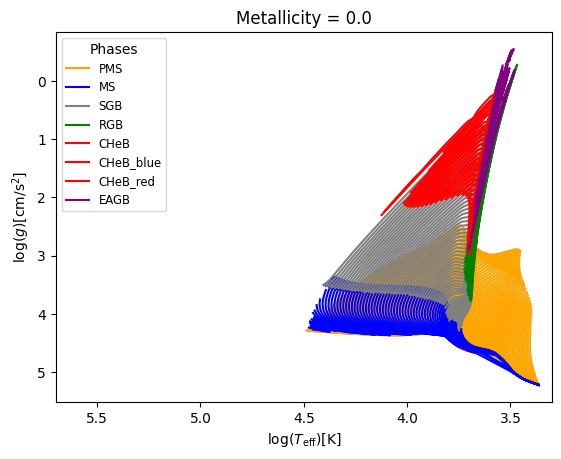

In [5]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['logAge', 'logTe', 'logg', 'label', 'metallicity', 'Mass', 'Rpol'], 
                              physical_model, rescale=False)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,logAge,logTe,logg,label,metallicity,Mass,Rpol
0,5.60000,4.4269,4.356,1.0,-0.25,9.714,3.428
1,5.65000,4.4266,4.355,1.0,-0.25,9.714,3.434
2,5.70000,4.4263,4.353,1.0,-0.25,9.714,3.440
3,5.75000,4.4061,4.358,1.0,-0.25,8.856,3.268
4,5.75000,4.4260,4.352,1.0,-0.25,9.714,3.447
...,...,...,...,...,...,...,...
321691,10.25002,3.6561,2.334,4.0,0.50,0.805,10.120
321692,10.25002,3.6560,2.333,4.0,0.50,0.805,10.130
321693,10.25002,3.6559,2.331,4.0,0.50,0.805,10.150
321694,10.25002,3.6558,2.330,4.0,0.50,0.805,10.160


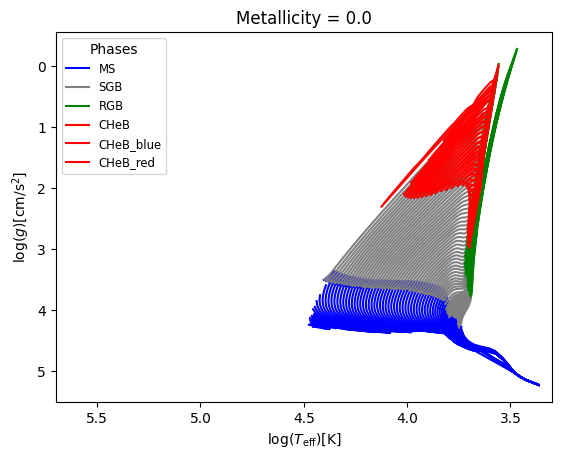

In [6]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'label':[1, 2, 3, 4, 5, 6]})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [7]:
print_all_uniques(phase_filtered_iso_df)

logAge  : Range : 5.3 - 10.25, Mean : 9.0428, Median : 9.3

logTe  : Range : 3.36 - 4.5177, Mean : 3.7779, Median : 3.721

logg  : Range : -0.38 - 5.345, Mean : 2.7607, Median : 2.486

Values in label column : 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.25, -2.5, -2.75, 0.0, 0.25, 0.5 

Mass  : Range : 0.09 - 13.952, Mean : 2.6725, Median : 1.428

Rpol  : Range : 0.11 - 687.5, Mean : 25.9755, Median : 10.37



In [8]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['logAge', 'logTe', 'logg', 'metallicity'], 
                               y_cols=['Mass', 'Rpol'], categories_cols=['label'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the Mass parameter : 0.09 - 13.943
Median value in train data for the Mass parameter: 1.427
Mean value in train data for the Mass parameter: 2.674483292715276

Range in train data for the Rpol parameter : 0.1056 - 687.5
Median value in train data for the Rpol parameter: 10.37
Mean value in train data for the Rpol parameter: 26.001361266951825

Testing set statistics:
Range in test data for the Mass parameter : 0.09 - 13.952
Median value in test data for the Mass parameter: 1.43
Mean value in test data for the Mass parameter: 2.6664658683974936

Range in test data for the Rpol parameter : 0.1056 - 679.2
Median value in test data for the Rpol parameter: 10.37
Mean value in test data for the Rpol parameter: 25.89790600566995

(241272, 4) (80424, 4)
(241272, 2) (80424, 2)


## Model training

### Linear regression

In [9]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.584323858959624
  RMSE :  1.9835004164899244
  MAE :  1.5029608797970555
  MedAE :  1.1947776005888149
  CORR :  0.7674653856808167
  MAX_ER :  8.10580392061424
  Percentiles : 
    75th percentile :  2.0691269327033477
    90th percentile :  2.734860257768144
    95th percentile :  3.970054715095076
    99th percentile :  6.679314940539292

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.6811186854281732
  RMSE :  1.941705516868006
  MAE :  1.399887585458173
  MedAE :  1.03650606557123
  CORR :  0.8387689874639916
  MAX_ER :  7.800581523746088
  Percentiles : 
    75th percentile :  1.5264901120290921
    90th percentile :  3.2274584060330533
    95th percentile :  4.723909332160269
    99th percentile :  6.315911277309322

mass results f

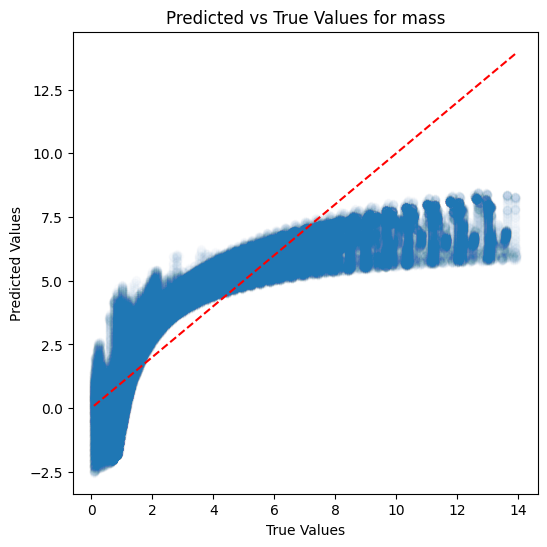

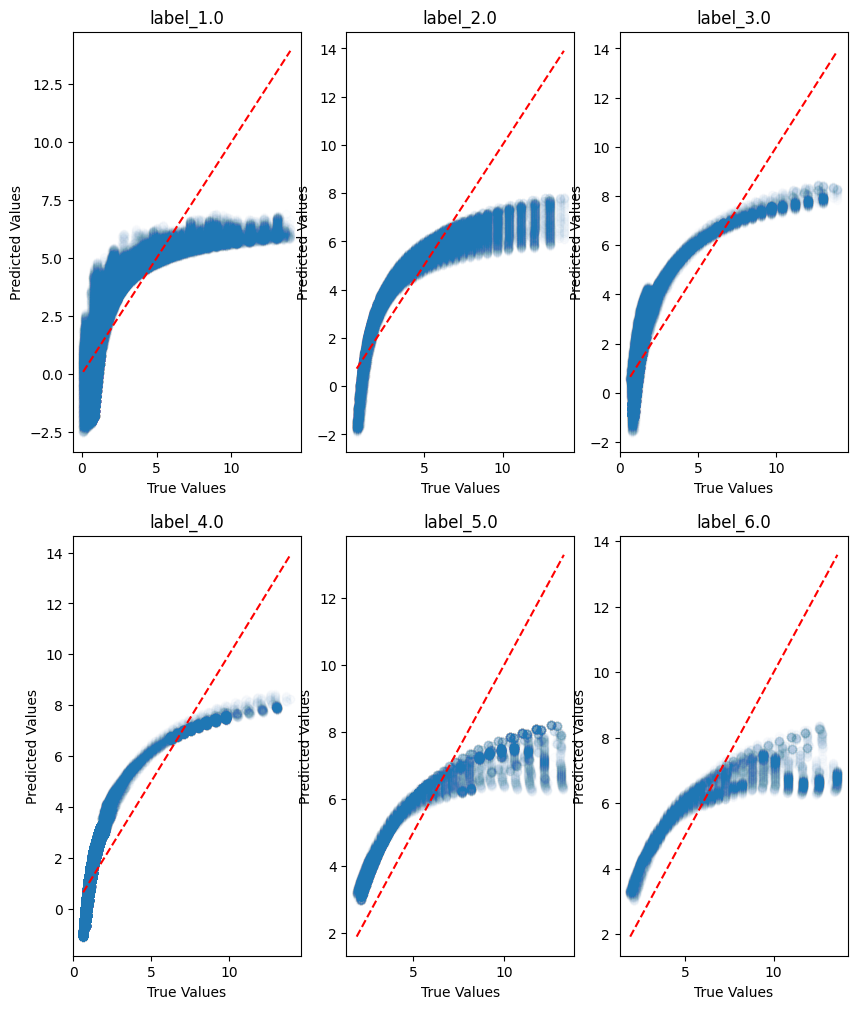

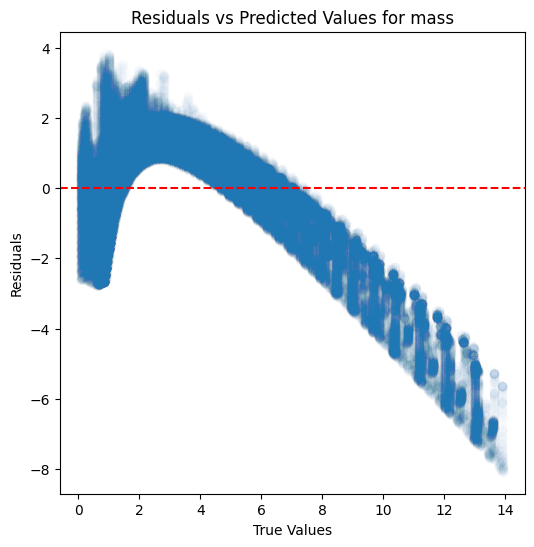

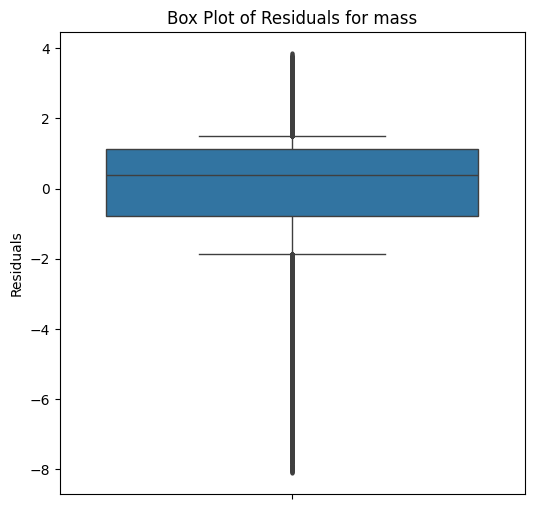

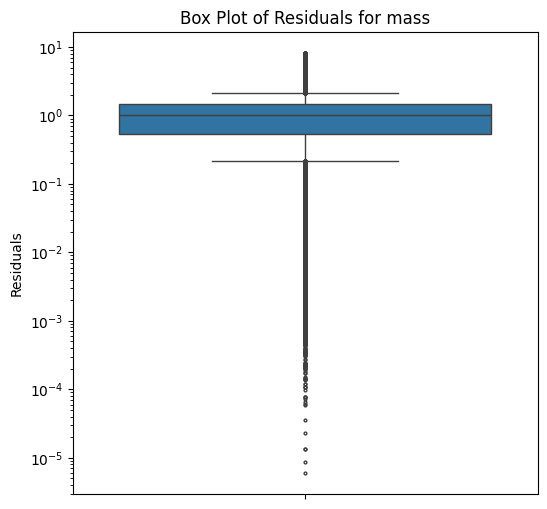

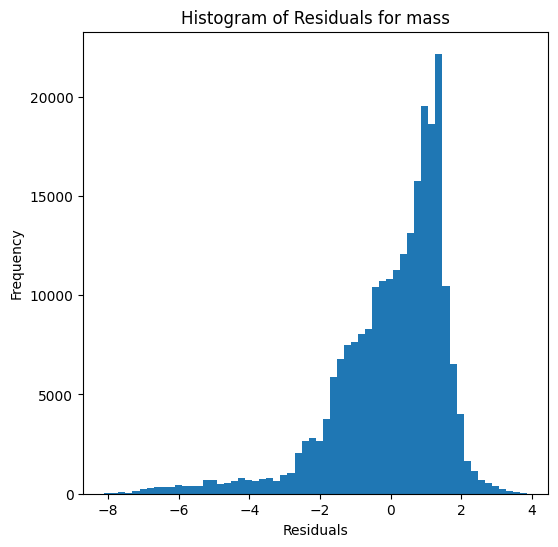

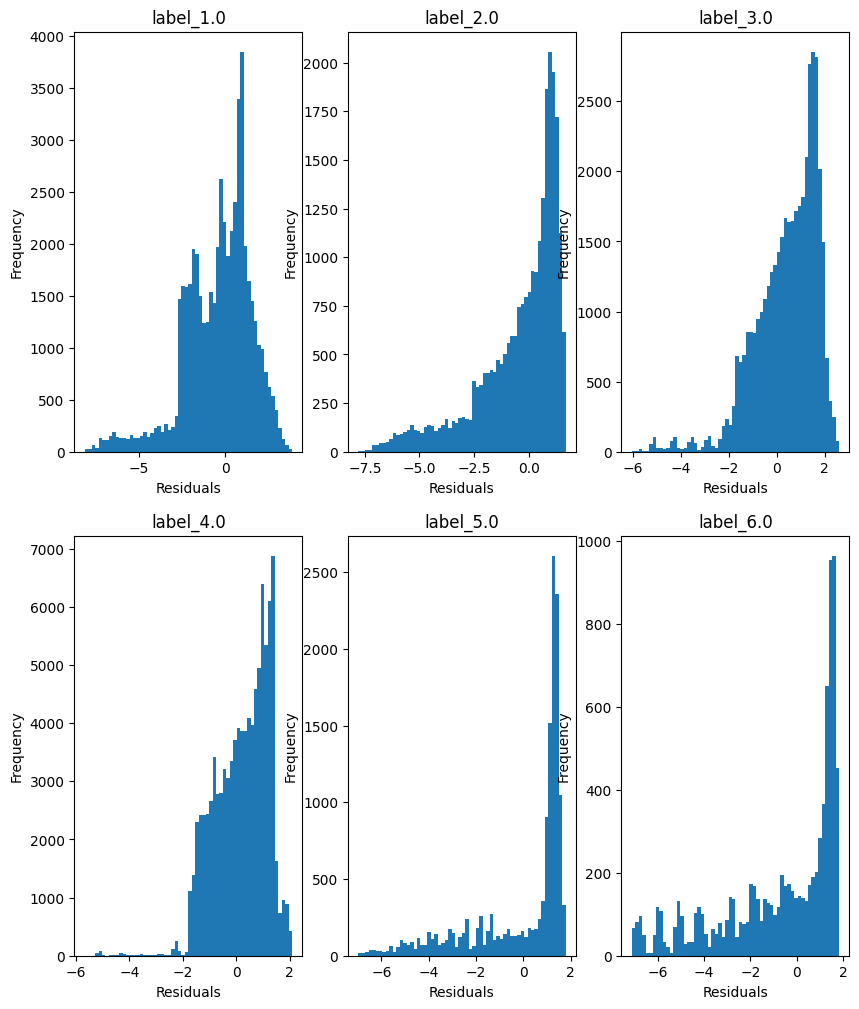

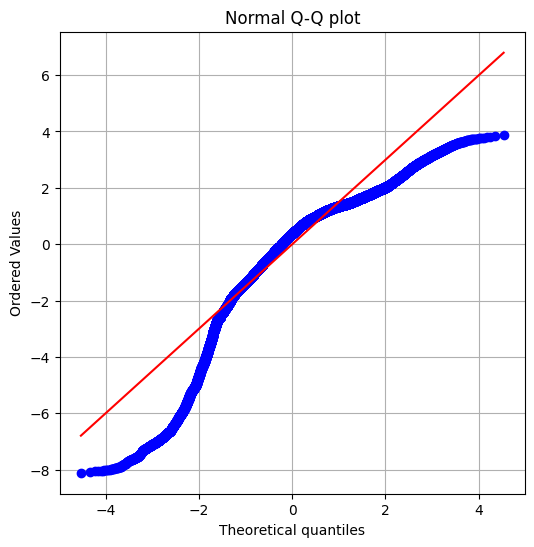

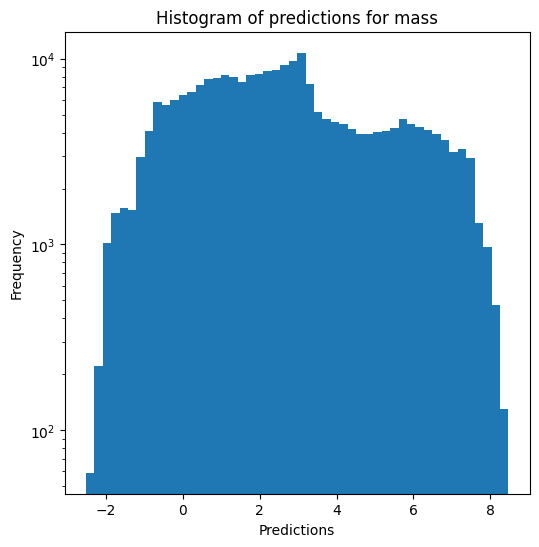

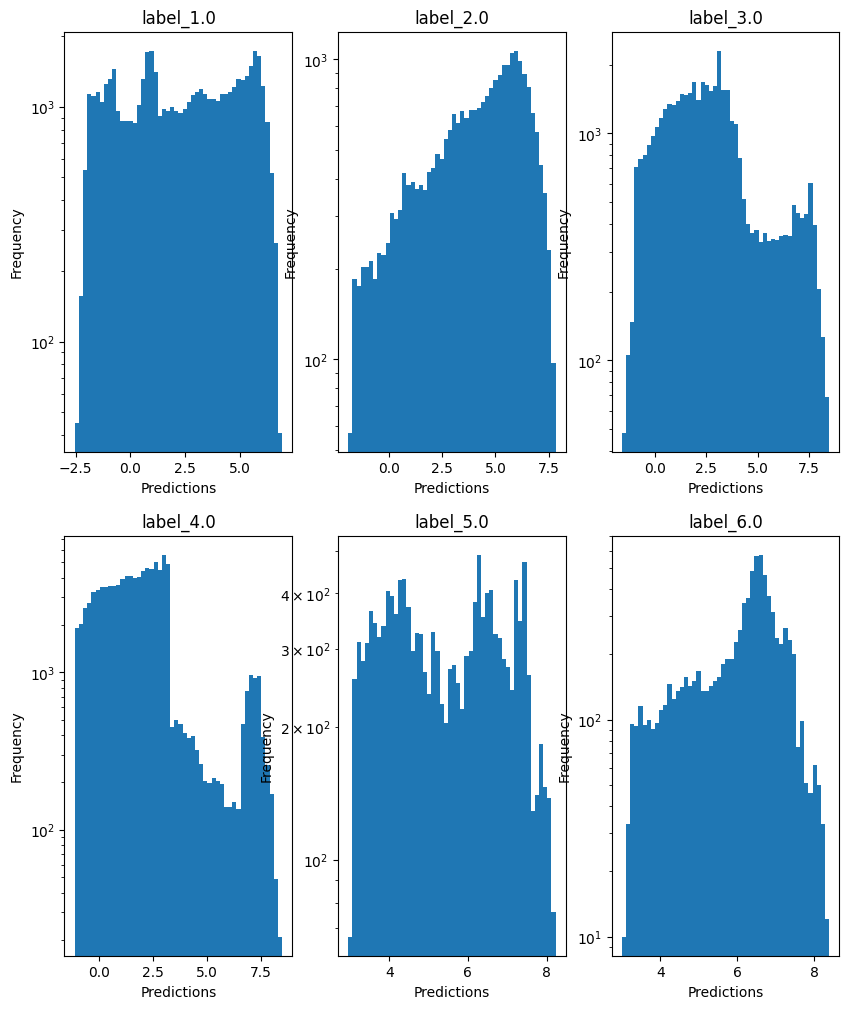

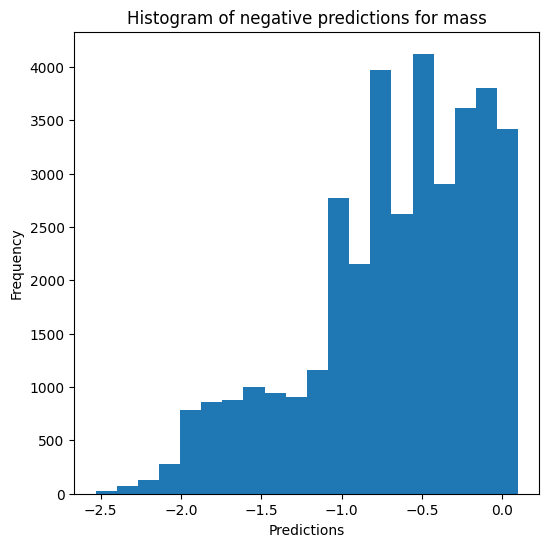


radius results for the label category with a value of 1.0
  value range :  0.1056 - 14.75
  RVE :  -229.4965805231799
  RMSE :  32.613822409651554
  MAE :  26.04980769622095
  MedAE :  21.433953806496415
  CORR :  0.8116299166651192
  MAX_ER :  87.95518305908652
  Percentiles : 
    75th percentile :  42.73281573573736
    90th percentile :  54.63083368600421
    95th percentile :  59.751156099090636
    99th percentile :  72.94929246426432

radius results for the label category with a value of 2.0
  value range :  1.047 - 287.4
  RVE :  0.49496547916755496
  RMSE :  27.05597227761753
  MAE :  22.813885149918047
  MedAE :  22.866156722955125
  CORR :  0.7691057098874661
  MAX_ER :  158.96331811342887
  Percentiles : 
    75th percentile :  32.206448772655364
    90th percentile :  36.776630102923505
    95th percentile :  39.221815779111836
    99th percentile :  69.38727863751143

radius results for the label category with a value of 3.0
  value range :  1.94 - 687.5
  RVE :  0.56558

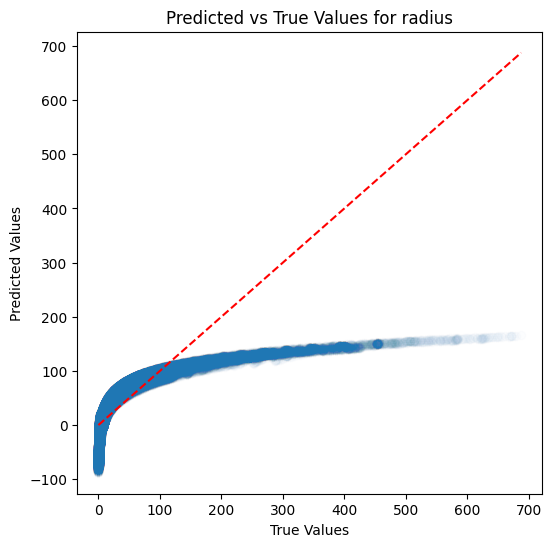

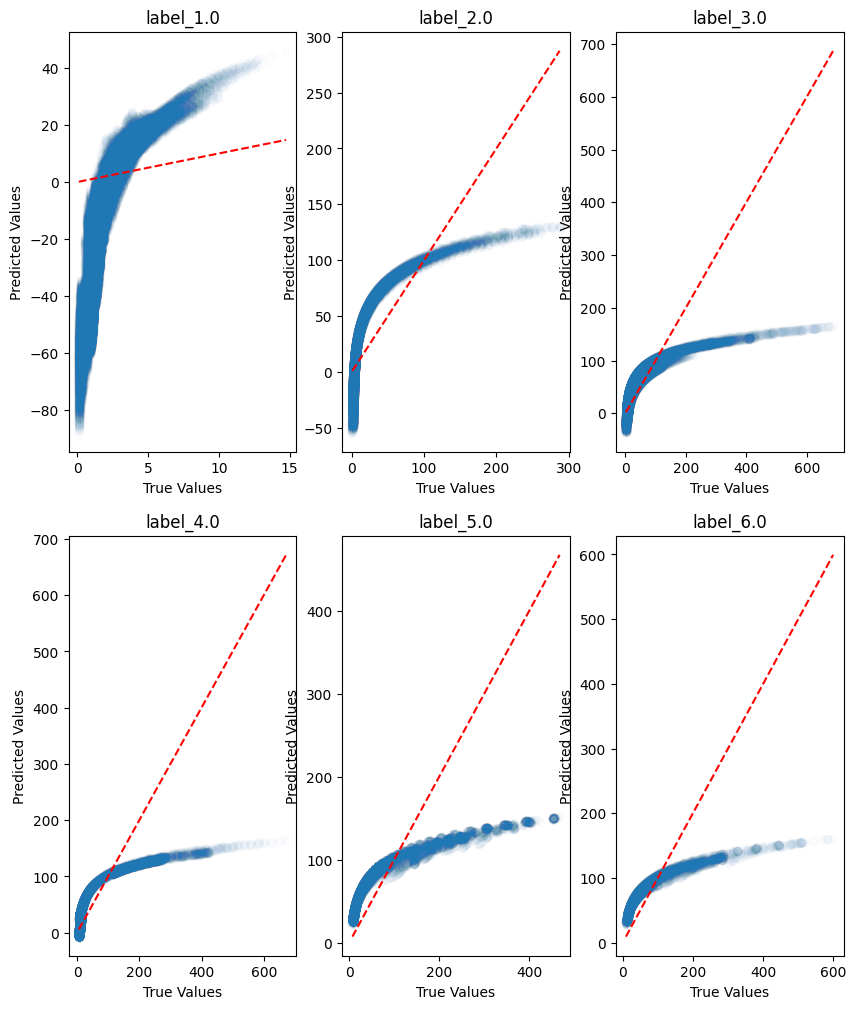

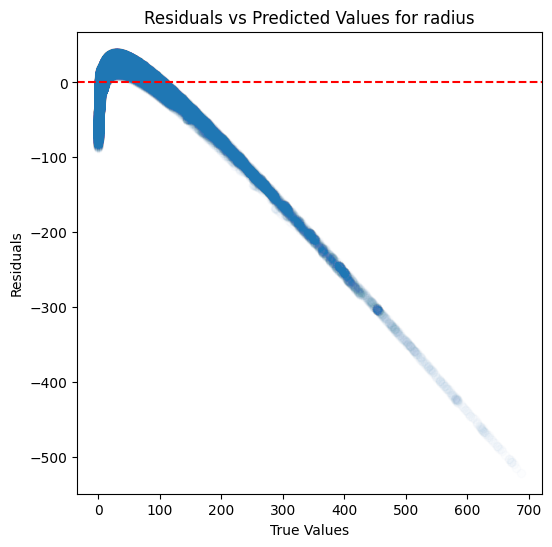

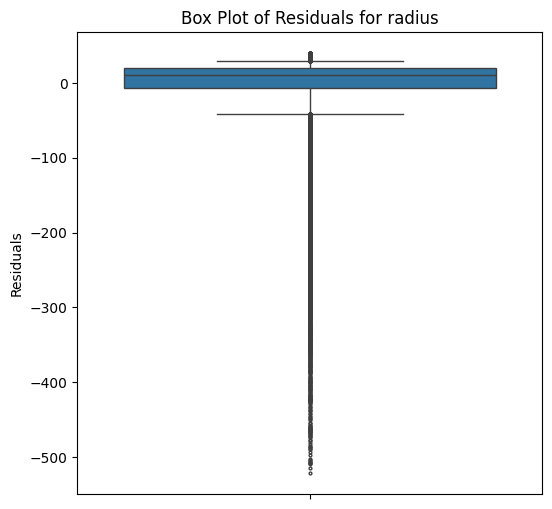

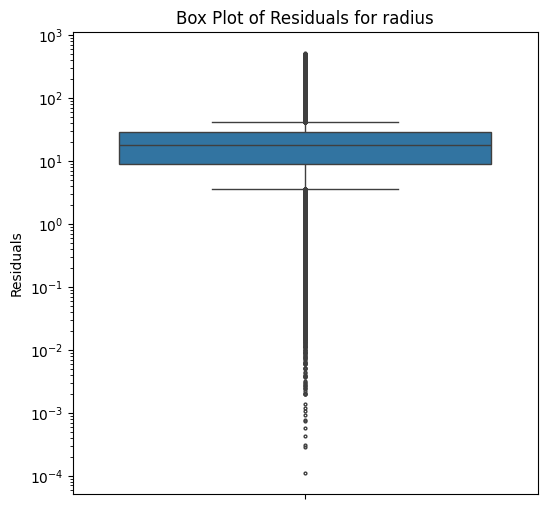

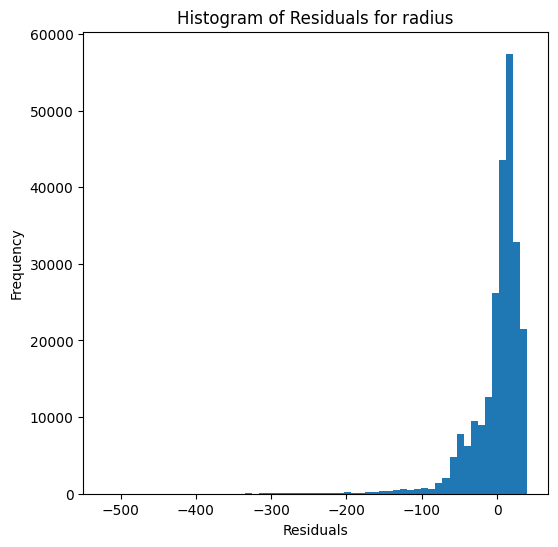

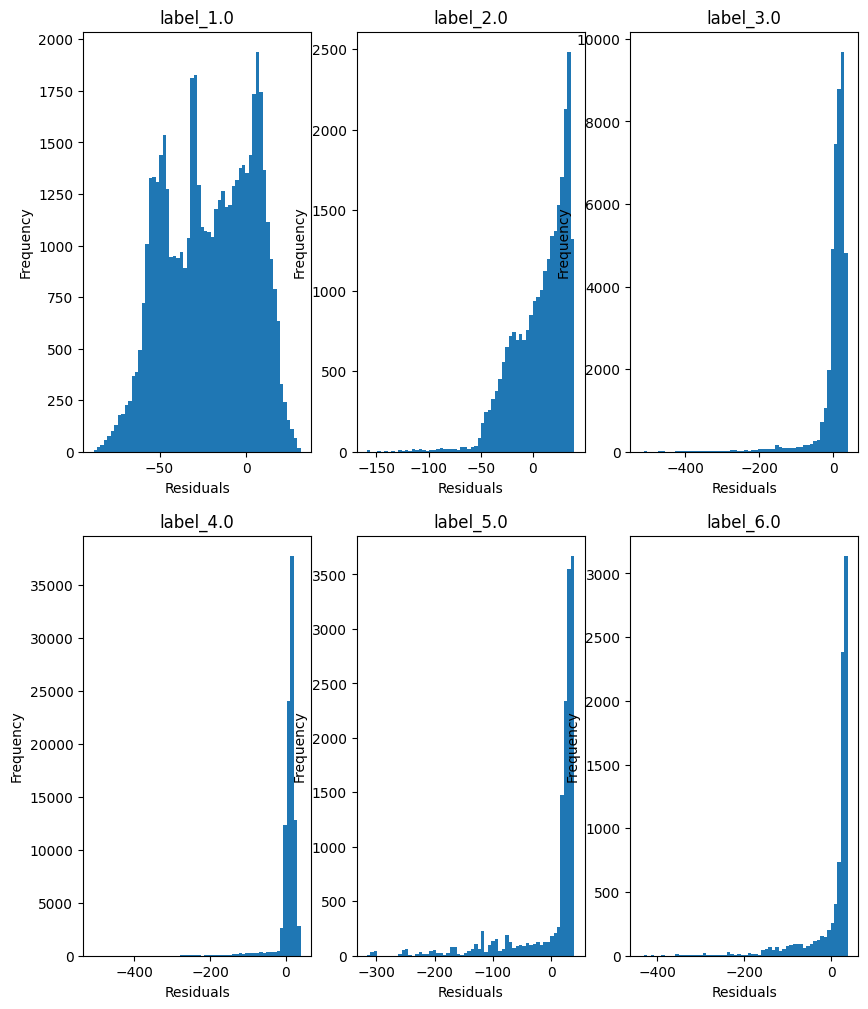

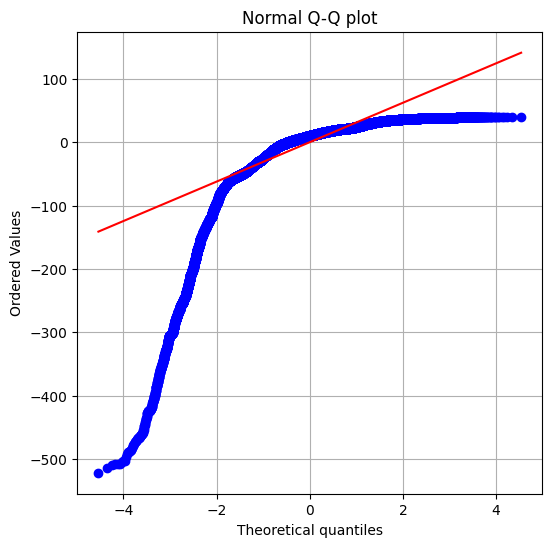

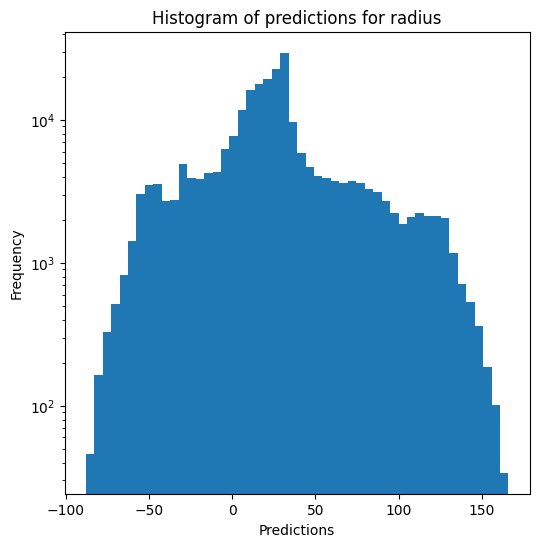

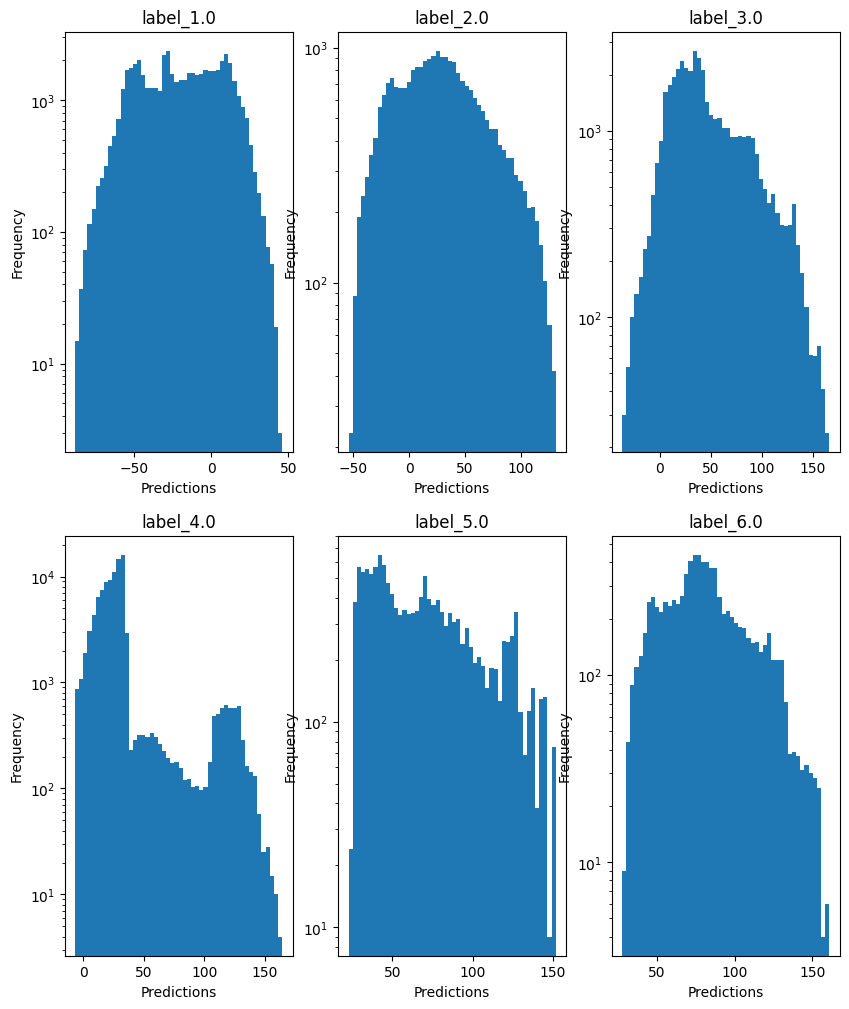

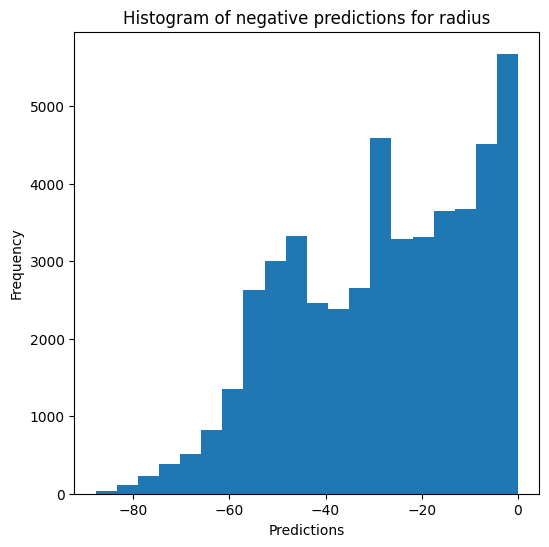

Saving predictions and results...


In [10]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [11]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9994743567744482
  RMSE :  0.06918831567065425
  MAE :  0.01680805542169113
  MedAE :  0.0
  CORR :  0.9997371507382846
  MAX_ER :  1.7029999999999994
  Percentiles : 
    75th percentile :  0.0010000000000000009
    90th percentile :  0.03300000000000036
    95th percentile :  0.09200000000000041
    99th percentile :  0.3409999999999993

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9973754017154567
  RMSE :  0.1719364174209157
  MAE :  0.0509393792622443
  MedAE :  0.0
  CORR :  0.998687905601706
  MAX_ER :  3.7119999999999997
  Percentiles : 
    75th percentile :  0.03200000000000003
    90th percentile :  0.13200000000000012
    95th percentile :  0.2519999999999998
    99th percentile :  0.7649999999999988

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.9991327760296551
  RMSE :

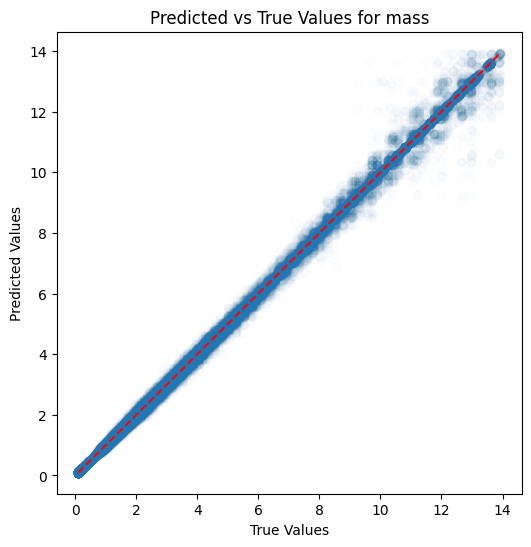

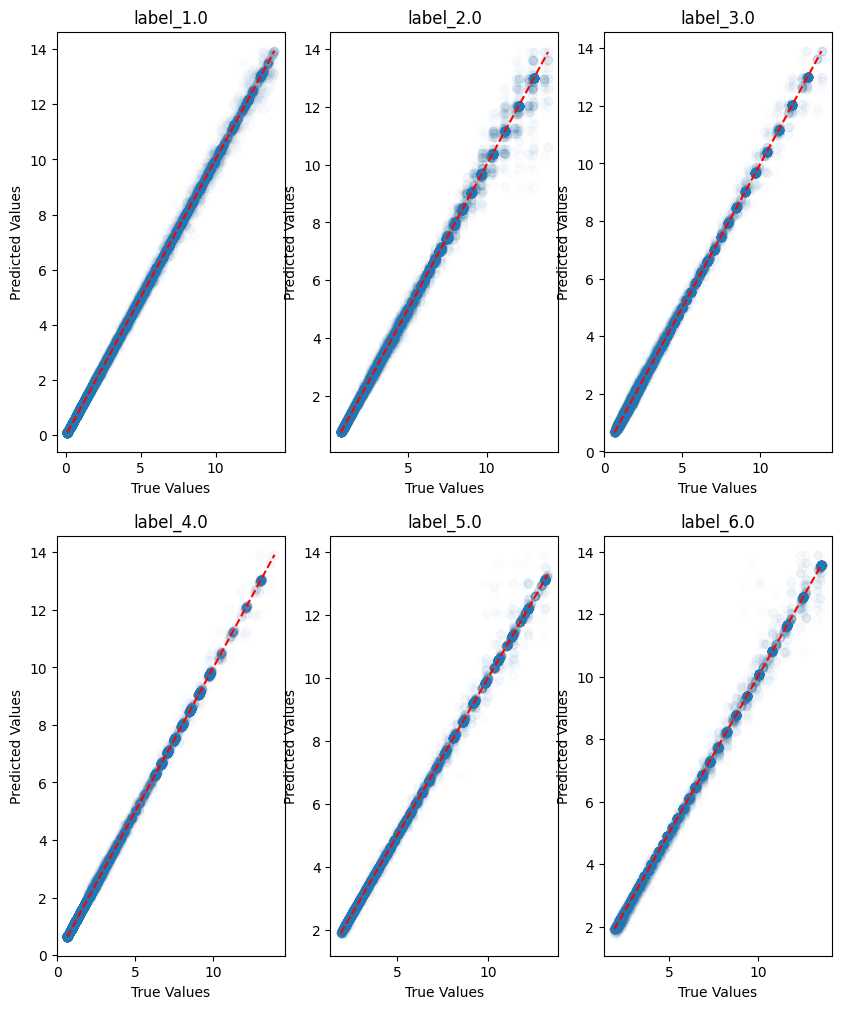

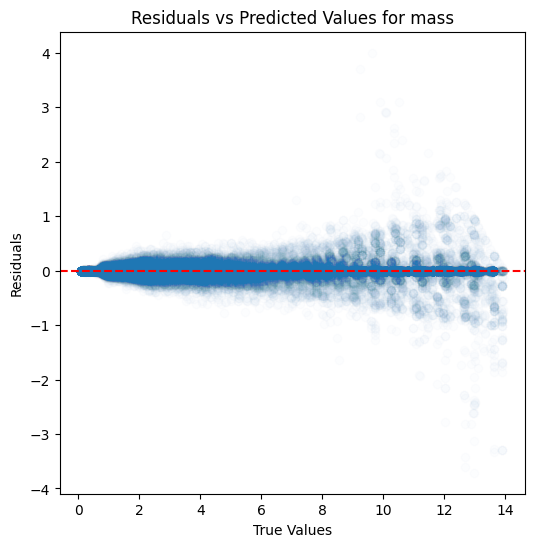

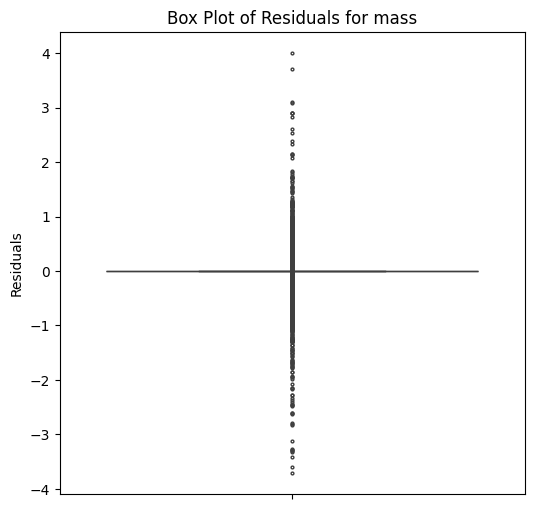

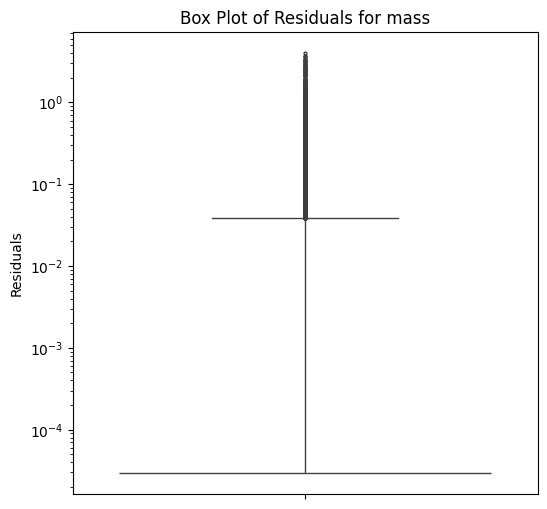

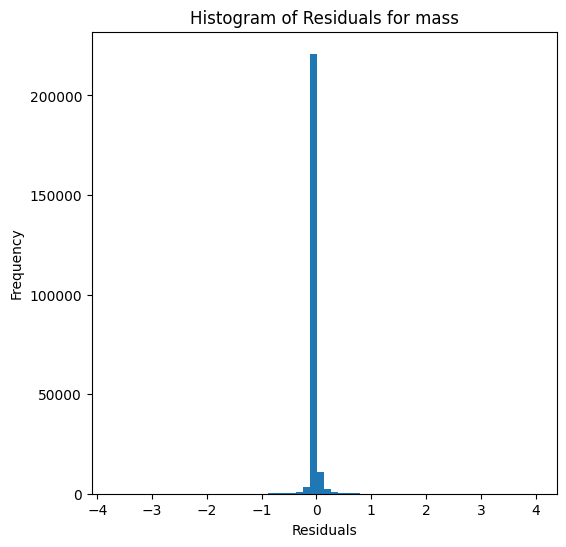

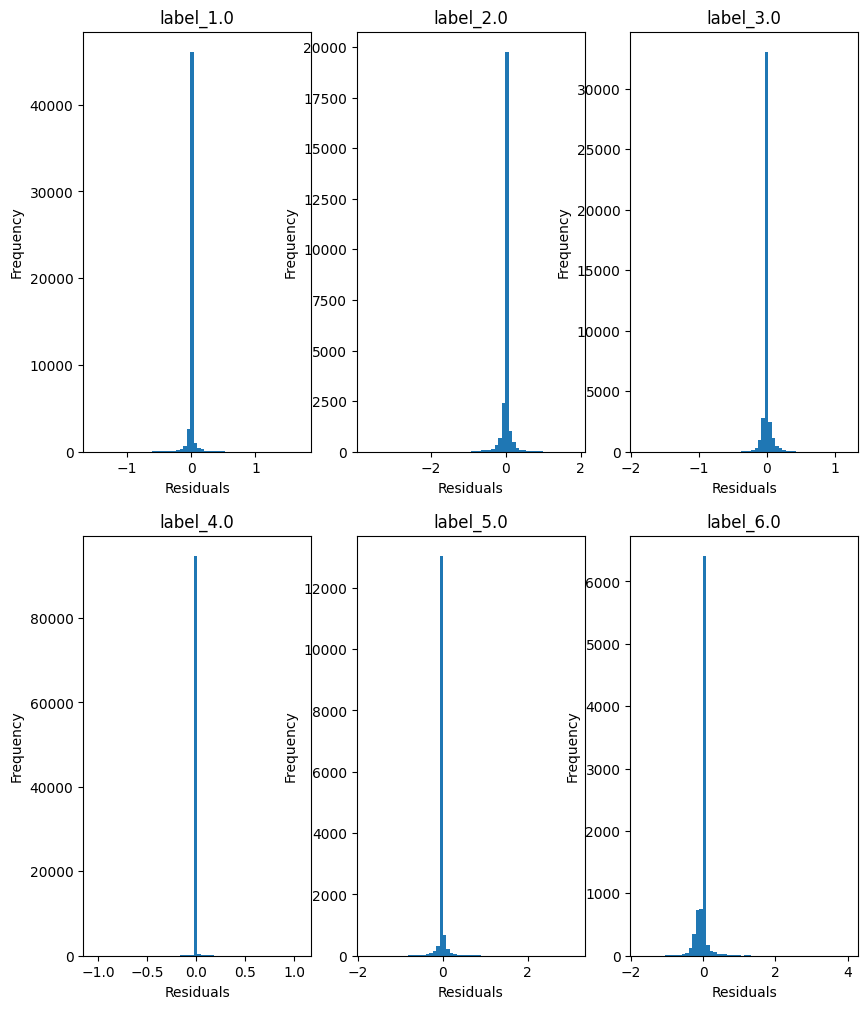

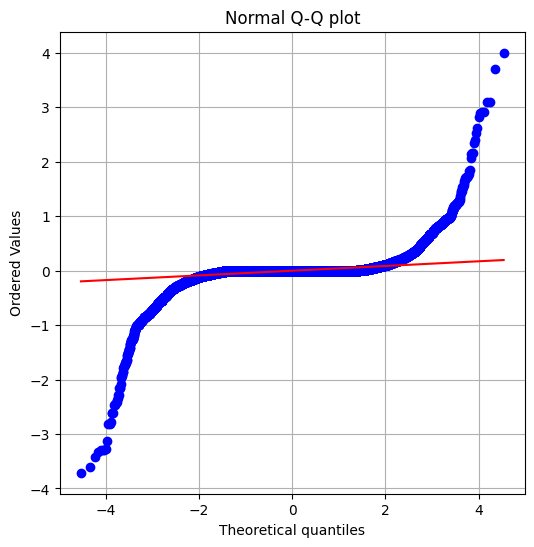

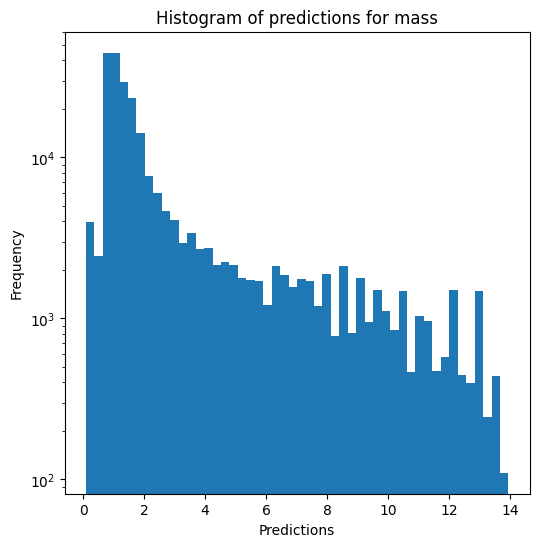

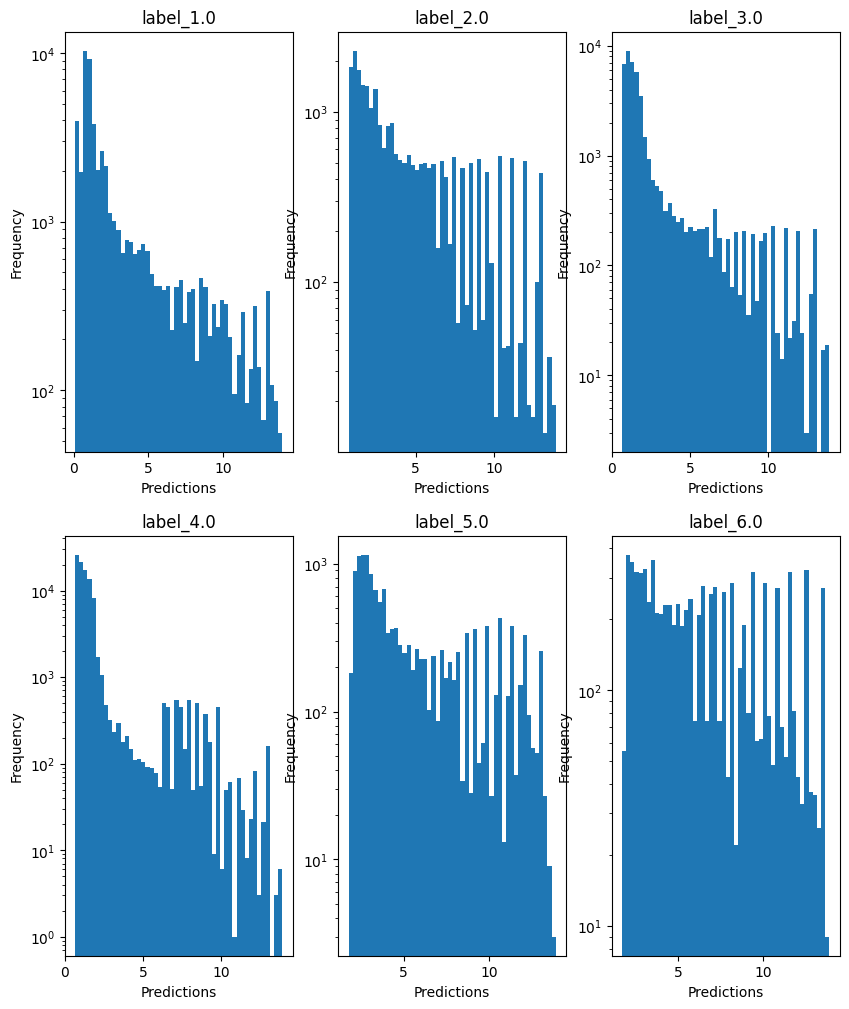

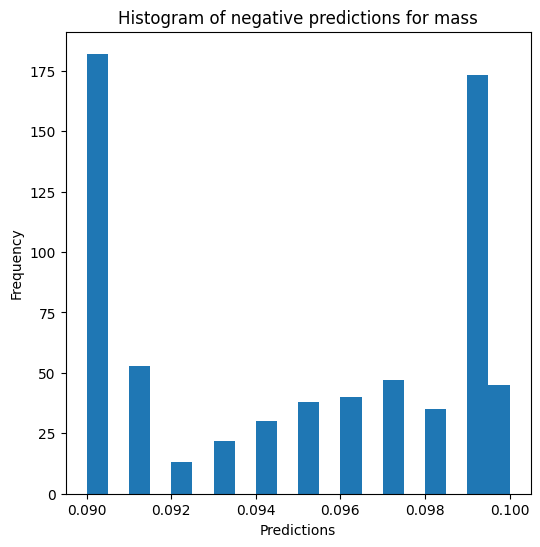

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


no negative values

radius results for the label category with a value of 1.0
  value range :  0.1056 - 14.75
  RVE :  0.9992200132407598
  RMSE :  0.04544948977109024
  MAE :  0.01326741399133282
  MedAE :  1.1102230246251565e-16
  CORR :  0.9996100768717389
  MAX_ER :  1.08
  Percentiles : 
    75th percentile :  0.0050000000000000044
    90th percentile :  0.03400000000000003
    95th percentile :  0.0730000000000004
    99th percentile :  0.21434999999999876

radius results for the label category with a value of 2.0
  value range :  1.047 - 287.4
  RVE :  0.9975629689661527
  RMSE :  1.8097182839899124
  MAE :  0.2387366514259146
  MedAE :  0.0
  CORR :  0.9988028257154833
  MAX_ER :  82.70000000000002
  Percentiles : 
    75th percentile :  0.06099999999999994
    90th percentile :  0.35129999999999995
    95th percentile :  0.8099999999999998
    99th percentile :  4.1186000000000105

radius results for the label category with a value of 3.0
  value range :  1.94 - 687.5
  RVE : 

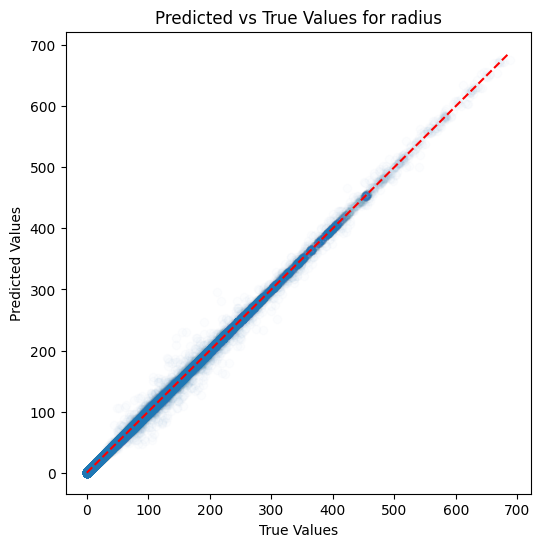

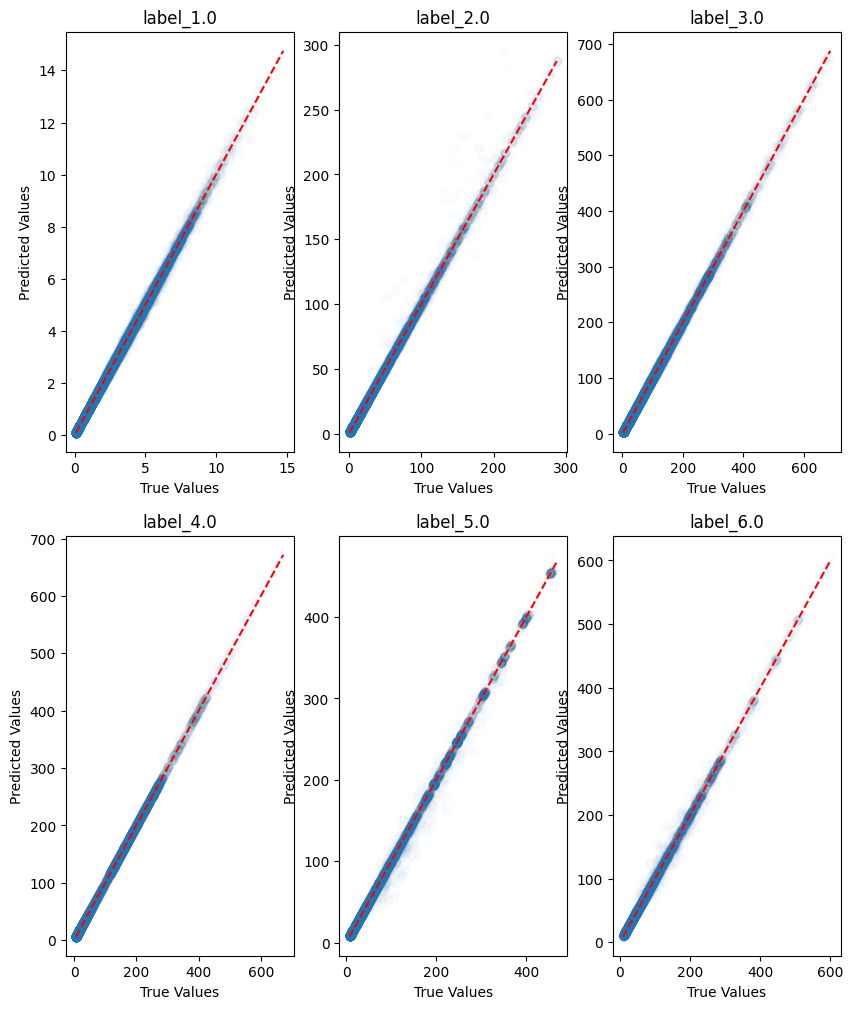

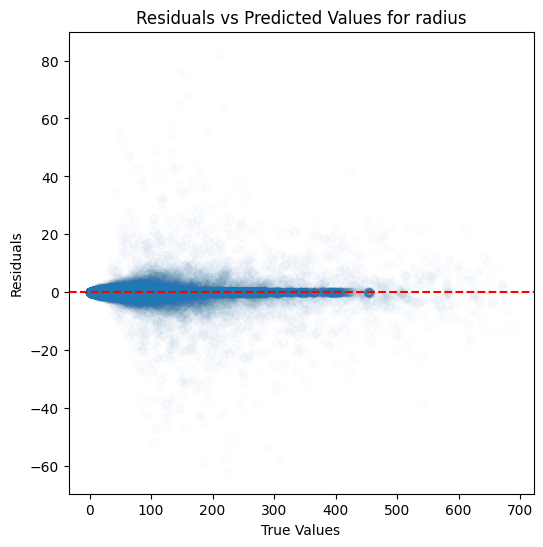

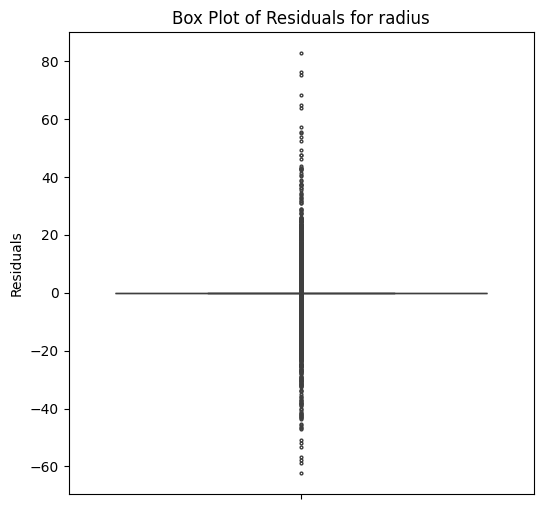

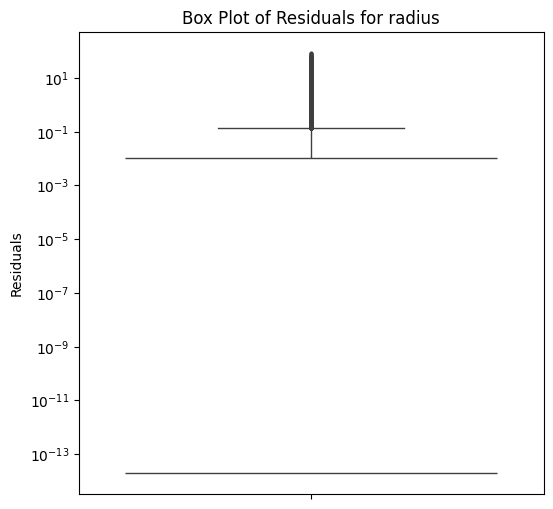

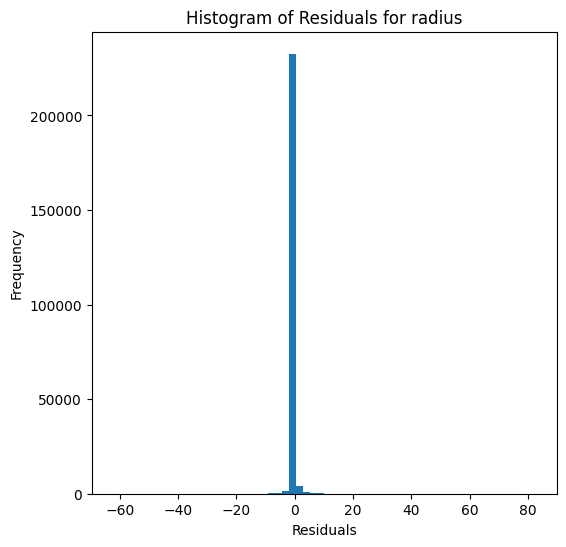

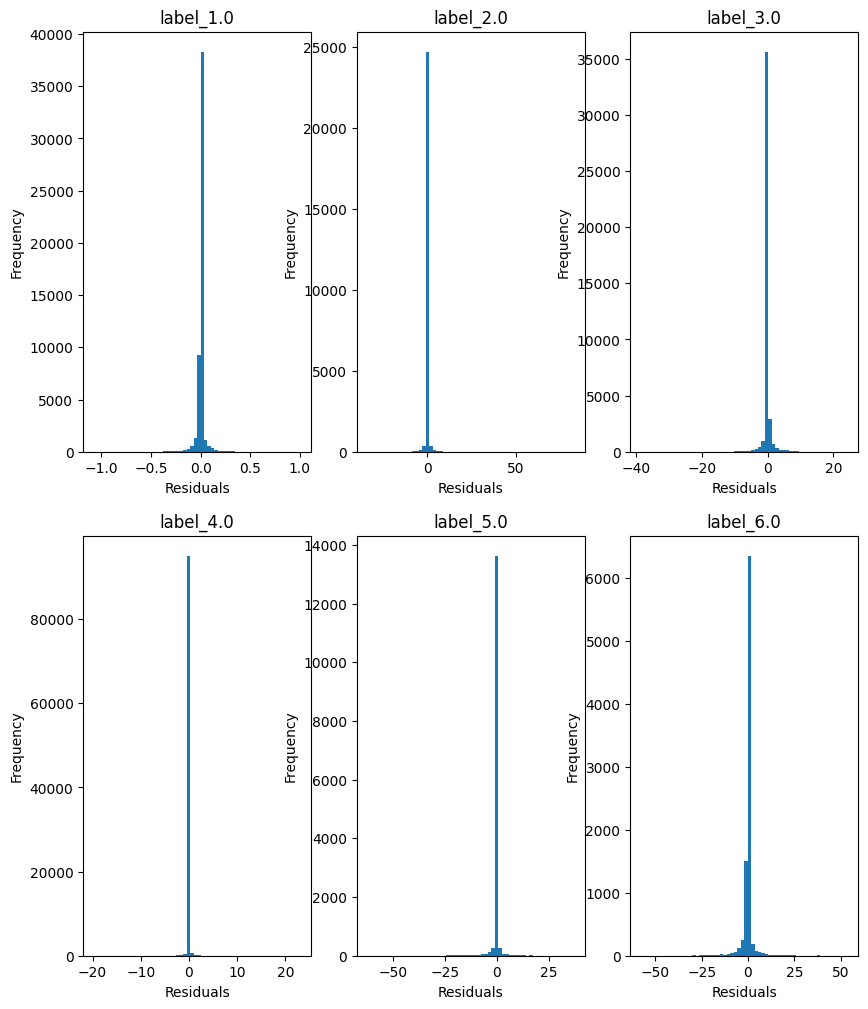

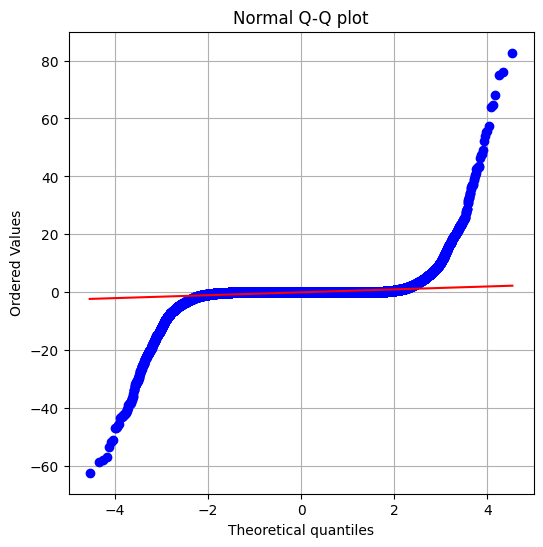

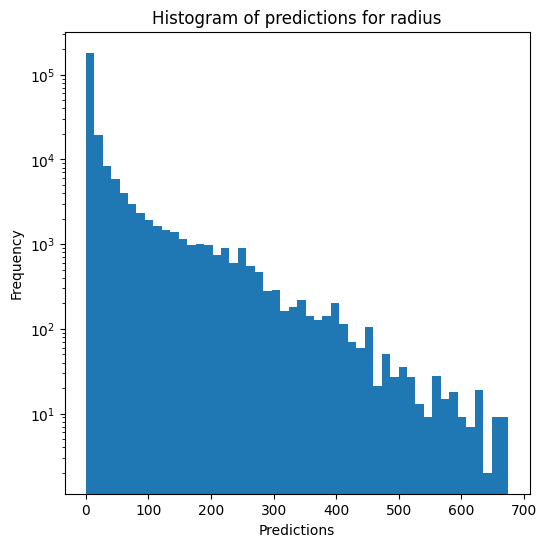

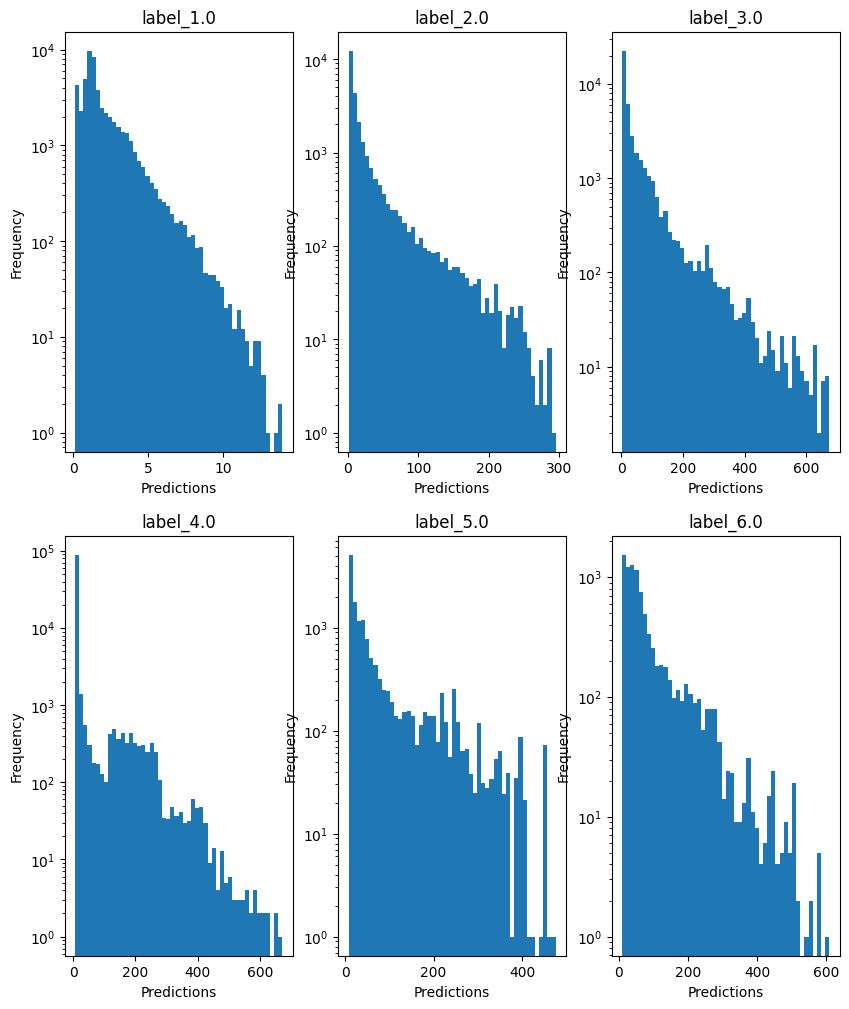

Saving predictions and results...


In [12]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [13]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...


c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9965086325857763
  RMSE :  0.17830533936952708
  MAE :  0.07693397263389302
  MedAE :  0.016600000000000004
  CORR :  0.9982626403190129
  MAX_ER :  3.3583999999999996
  Percentiles : 
    75th percentile :  0.0706
    90th percentile :  0.21890000000000054
    95th percentile :  0.3685999999999996
    99th percentile :  0.8268000000000004

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9965995955985715
  RMSE :  0.19644558989899102
  MAE :  0.08831885461872288
  MedAE :  0.022399999999999753
  CORR :  0.998303232425027
  MAX_ER :  1.9445999999999994
  Percentiles : 
    75th percentile :  0.08640000000000025
    90th percentile :  0.2510600000000004
    95th percentile :  0.4050000000000005
    99th percentile :  0.926585999999999

mass results for the label category with a value of 3.0
  value range :  0.655 - 13.903
  RVE :  0.9987999

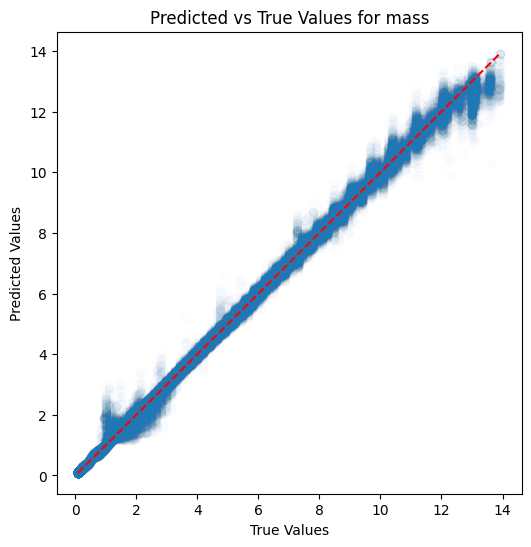

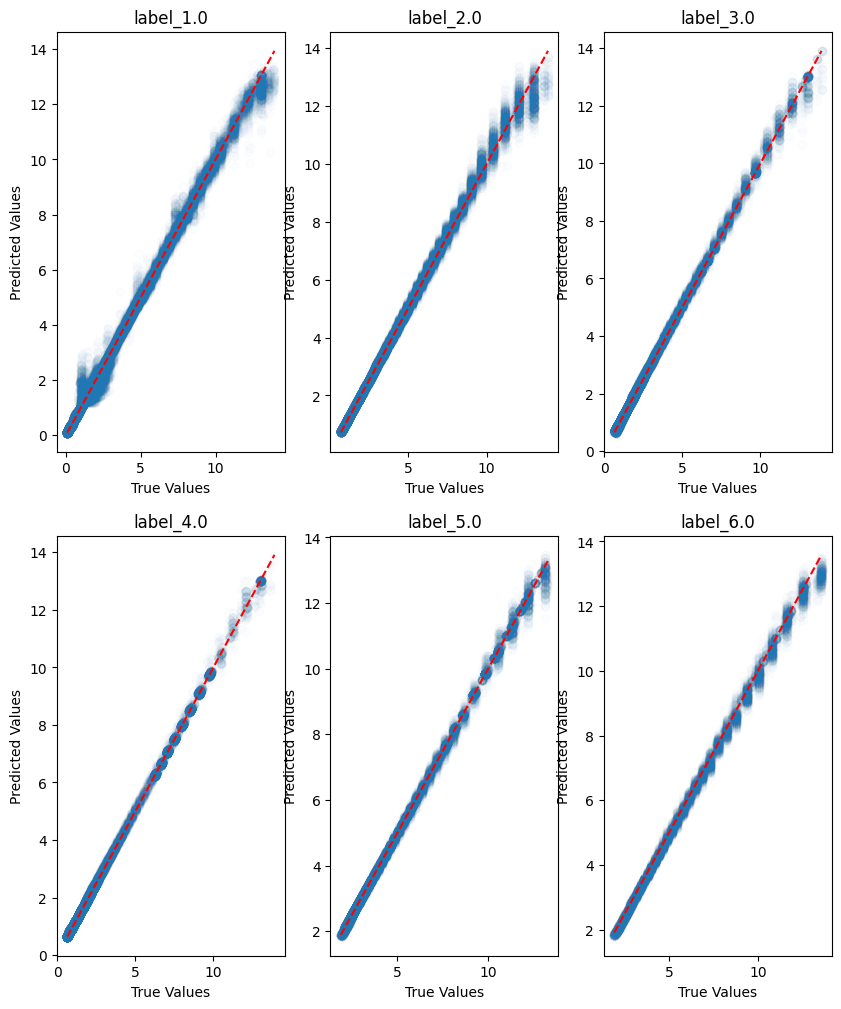

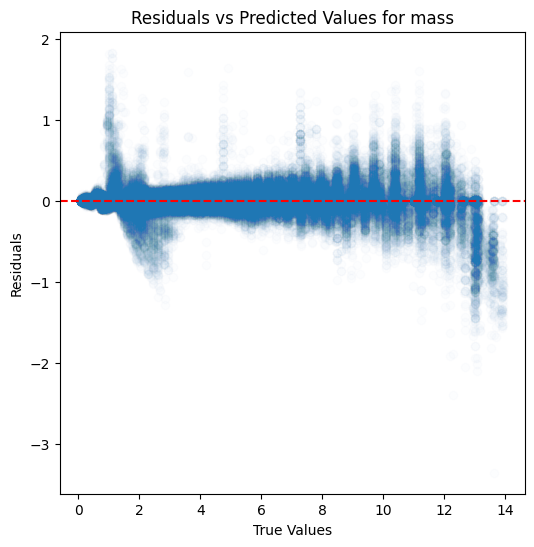

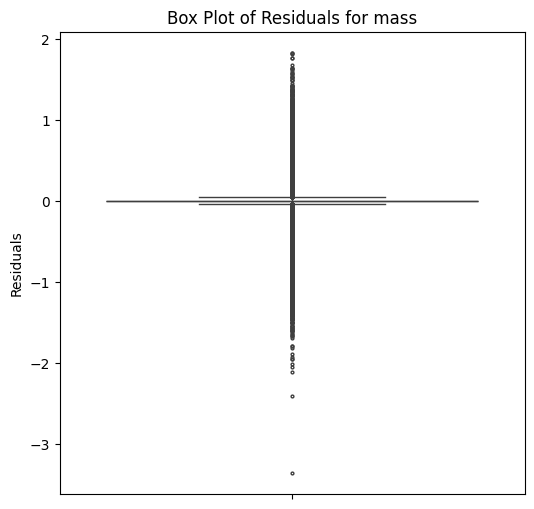

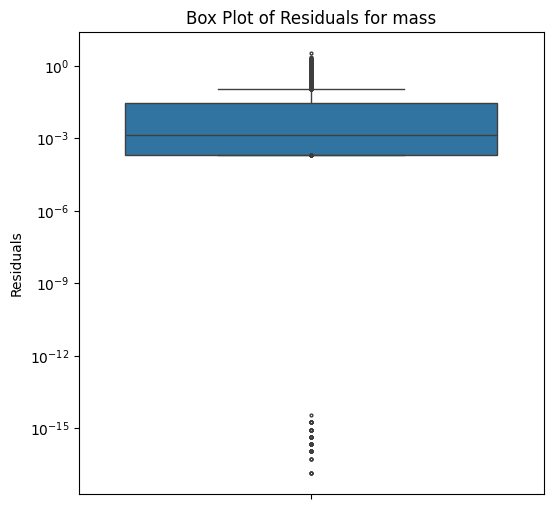

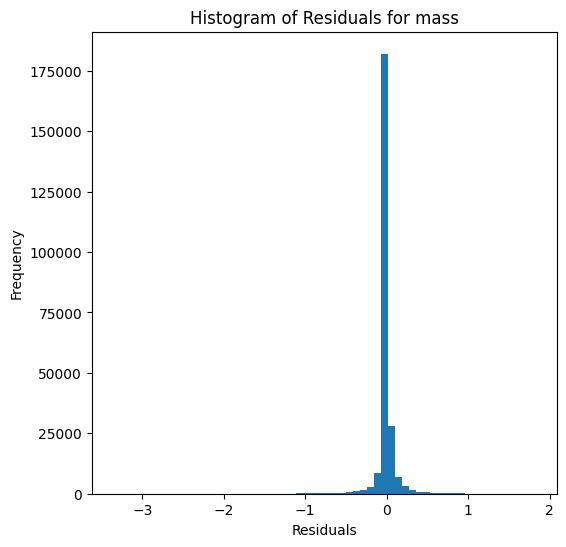

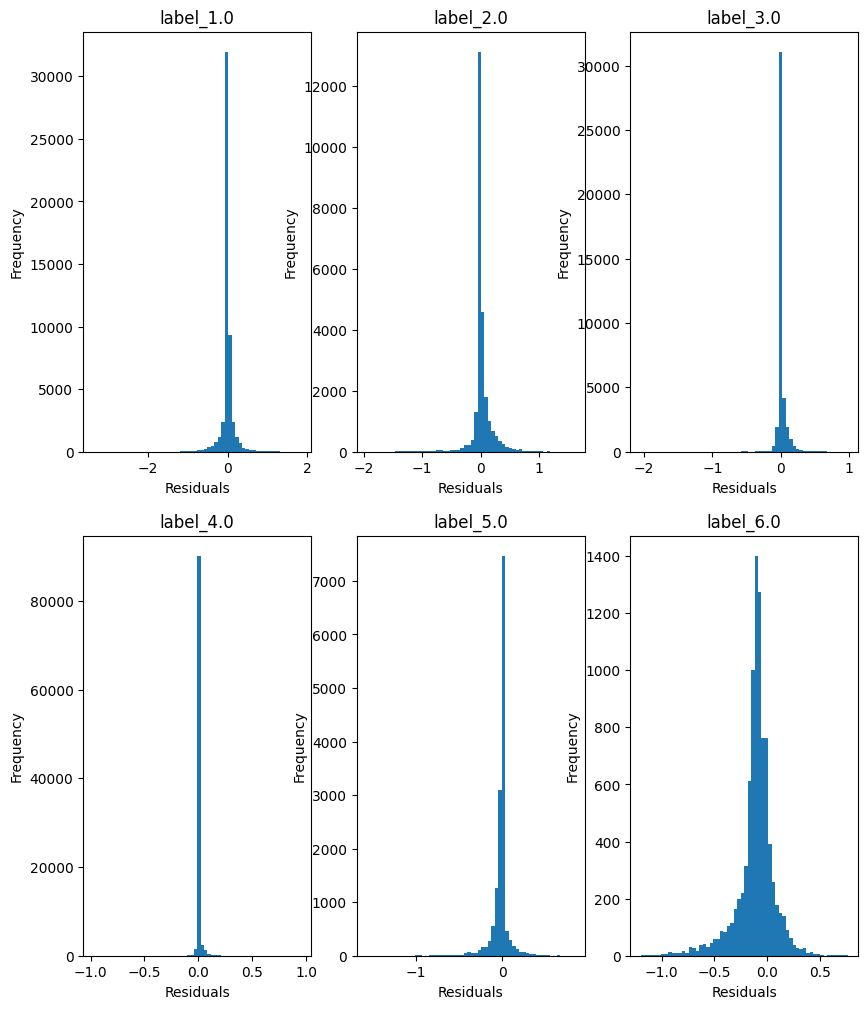

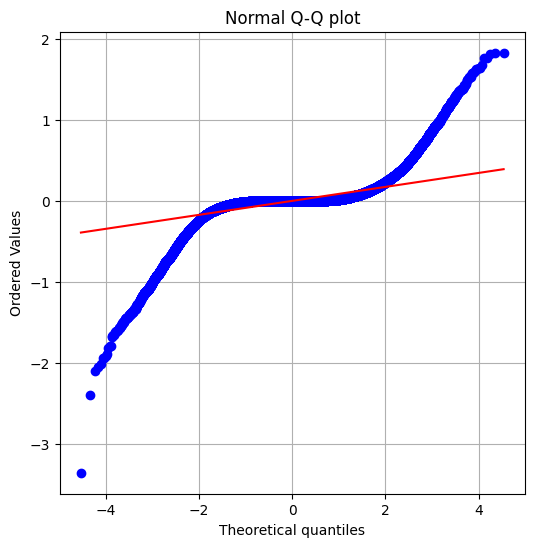

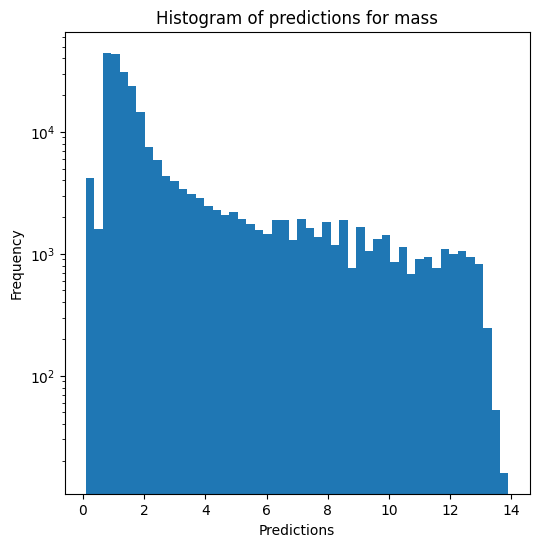

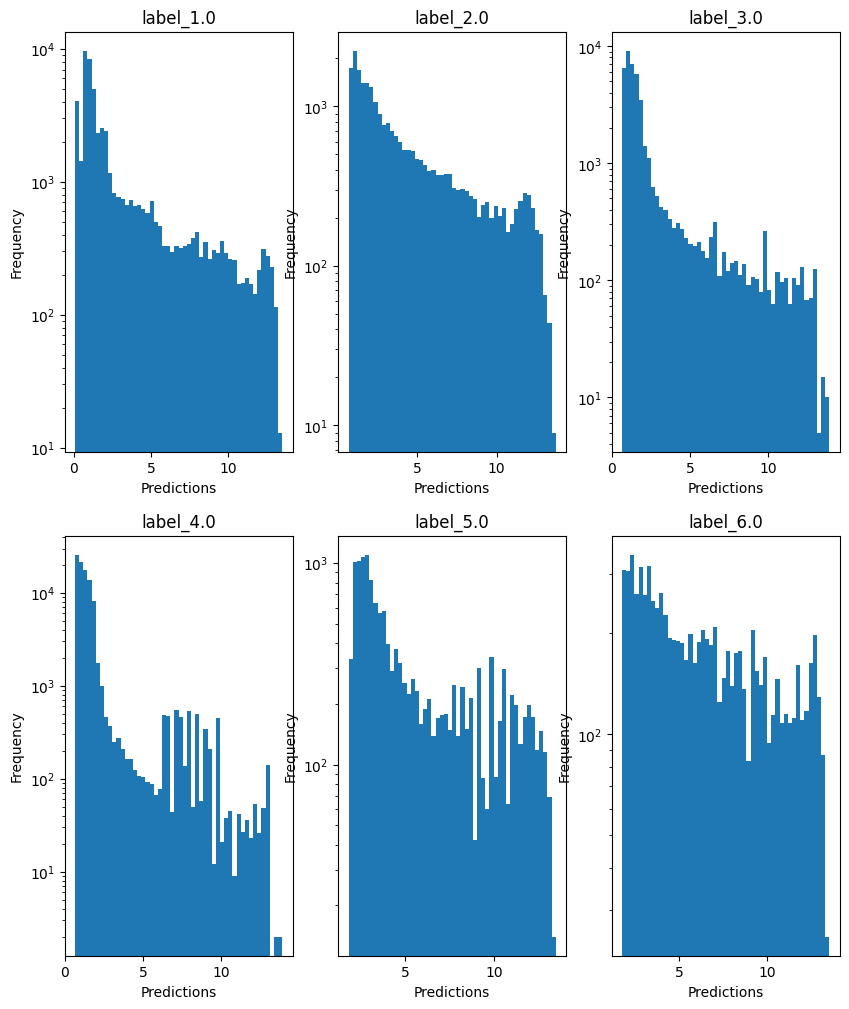

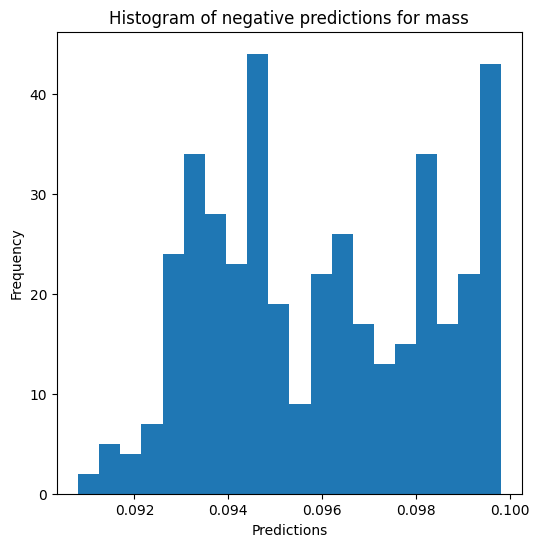

no negative values

radius results for the label category with a value of 1.0
  value range :  0.1056 - 14.75
  RVE :  0.9982289953075999
  RMSE :  0.0684915897267565
  MAE :  0.03719255164310351
  MedAE :  0.016999999999999904
  CORR :  0.9991147016462281
  MAX_ER :  0.9379999999999988
  Percentiles : 
    75th percentile :  0.04560000000000031
    90th percentile :  0.0958
    95th percentile :  0.14694999999999903
    99th percentile :  0.28400000000000003

radius results for the label category with a value of 2.0
  value range :  1.047 - 287.4
  RVE :  0.9863288656026867
  RMSE :  4.359306883202778
  MAE :  0.9948446094234346
  MedAE :  0.07340000000000035
  CORR :  0.9953174003811739
  MAX_ER :  104.5
  Percentiles : 
    75th percentile :  0.27199999999999847
    90th percentile :  1.1006000000000036
    95th percentile :  4.169899999999989
    99th percentile :  19.5

radius results for the label category with a value of 3.0
  value range :  1.94 - 687.5
  RVE :  0.9989924294854

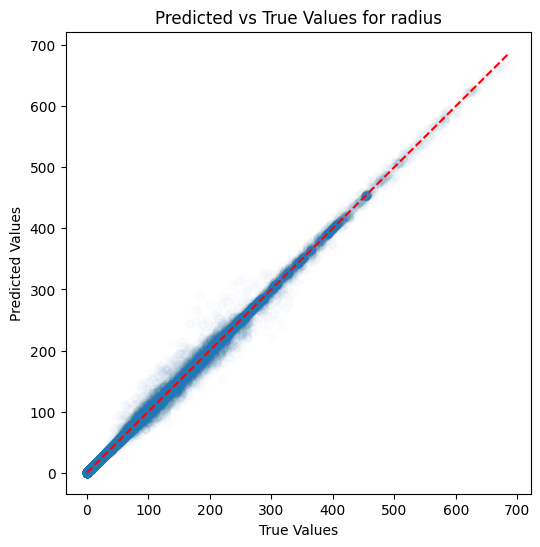

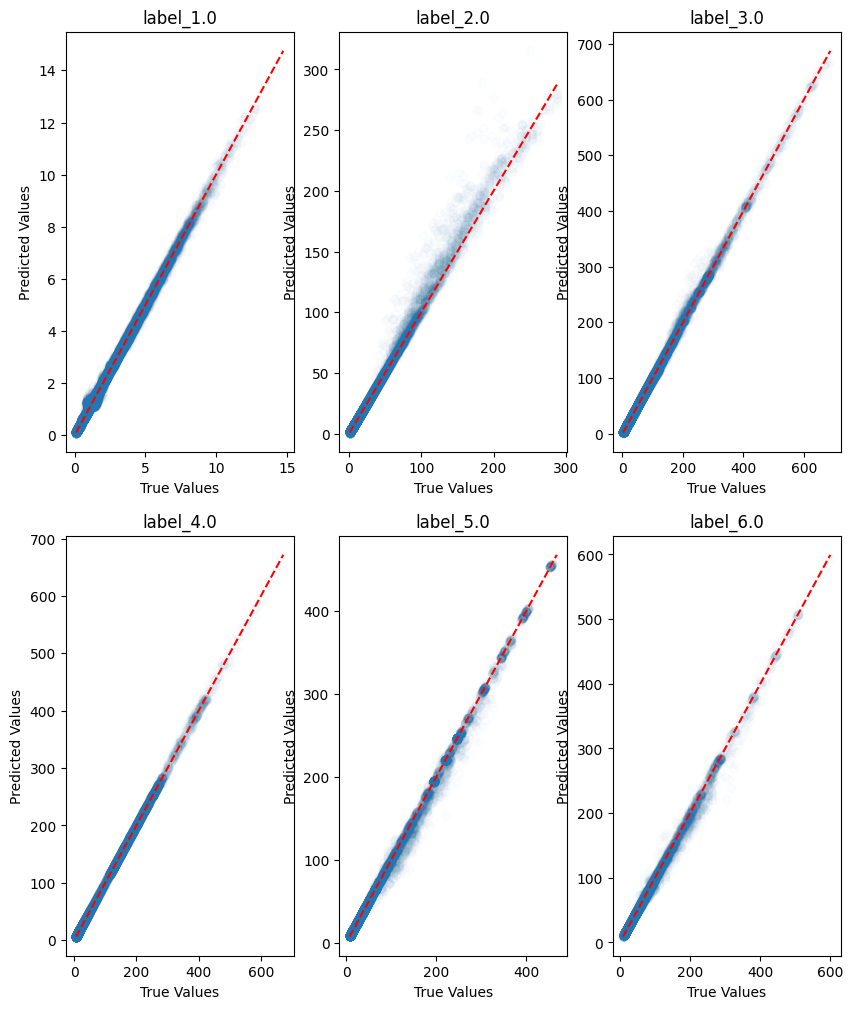

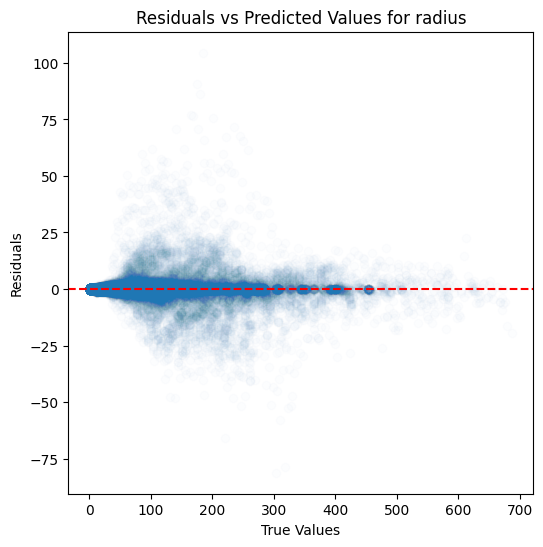

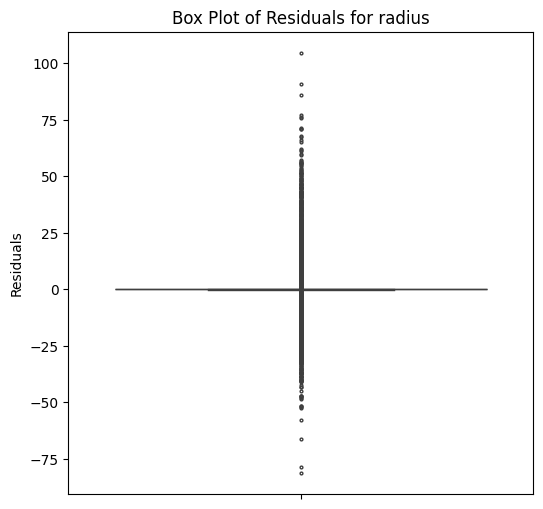

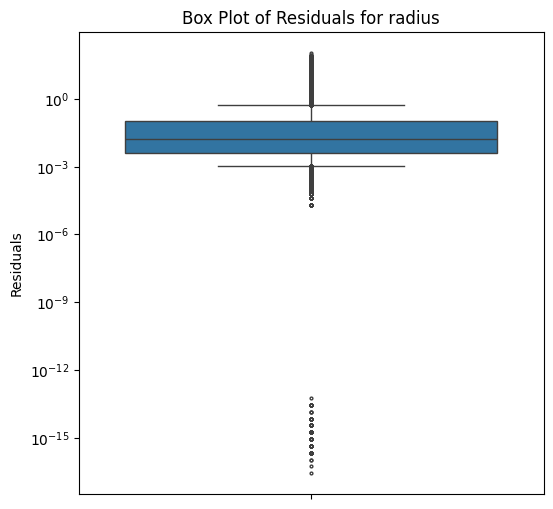

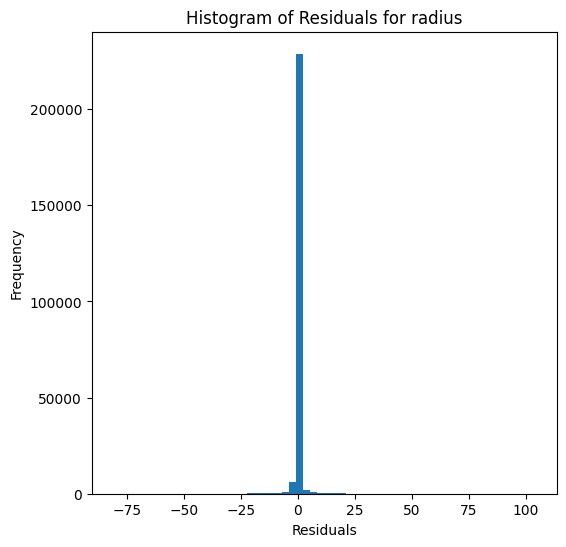

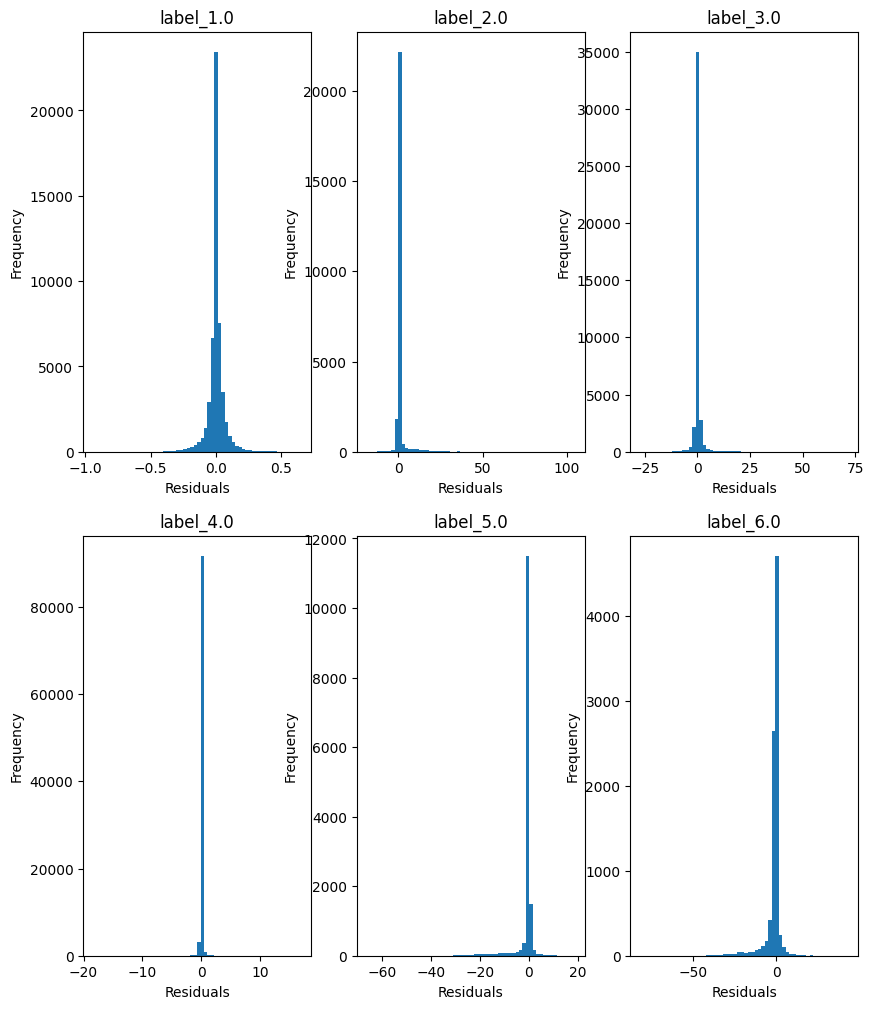

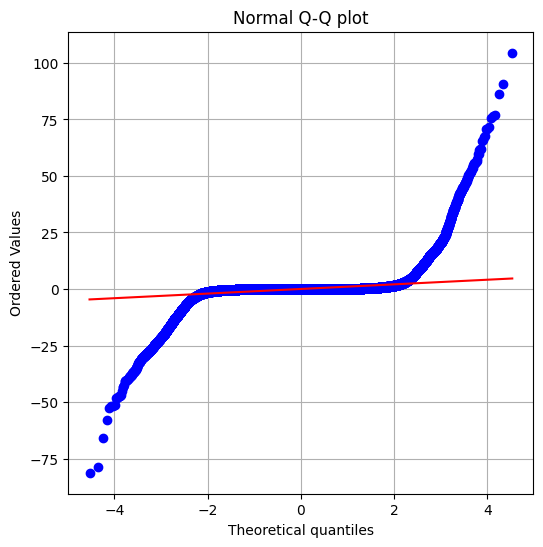

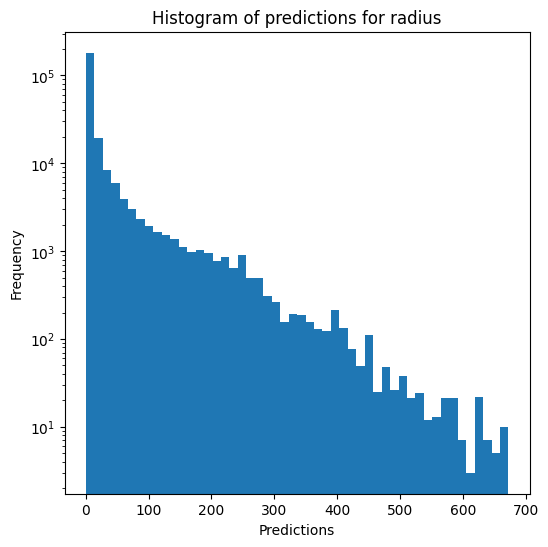

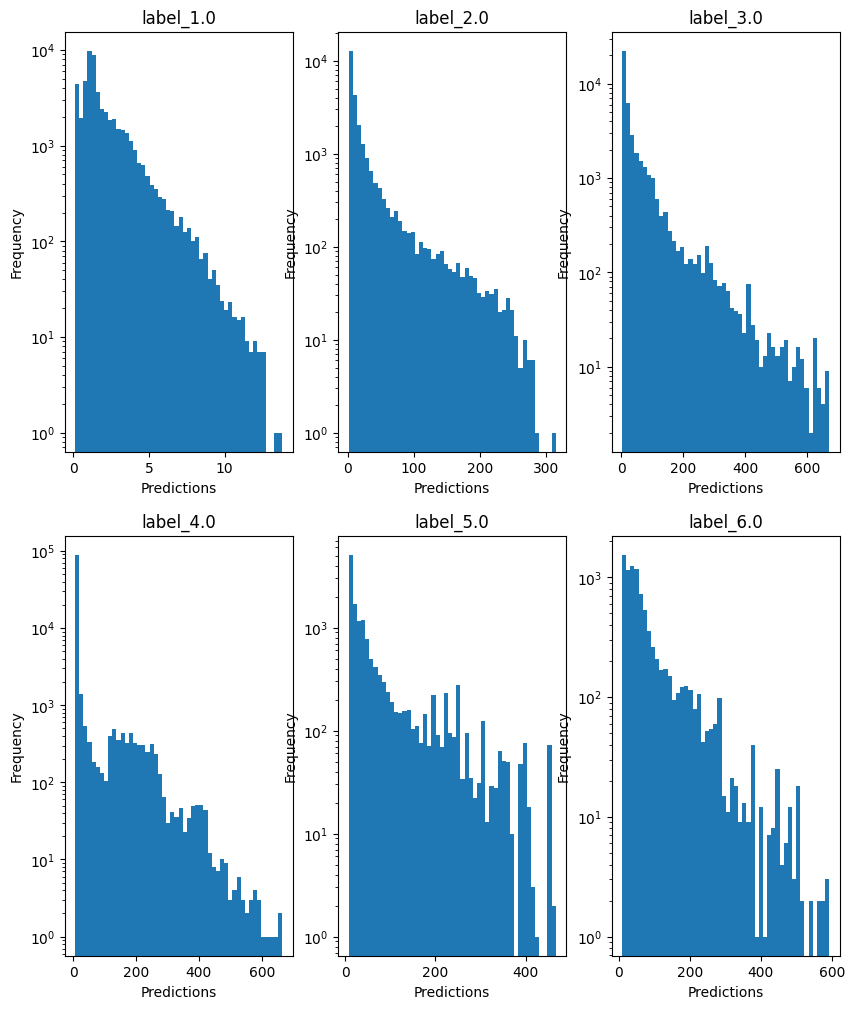

Saving predictions and results...


In [14]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [15]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9998531149467009
  RMSE :  0.036594437162732446
  MAE :  0.009966621720755488
  MedAE :  0.0004099999999982451
  CORR :  0.9999268679849963
  MAX_ER :  1.0233999999999952
  Percentiles : 
    75th percentile :  0.0044099999999999695
    90th percentile :  0.024059999999998416
    95th percentile :  0.04986750000000029
    99th percentile :  0.16043041666666605

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9990944310275959
  RMSE :  0.10138447723166924
  MAE :  0.03196821656721507
  MedAE :  0.004110000000014047
  CORR :  0.999554754305596
  MAX_ER :  1.9606199999999934
  Percentiles : 
    75th percentile :  0.022500000000000298
    90th percentile :  0.07979300000000505
    95th percentile :  0.13913800000000054
    99th percentile :  

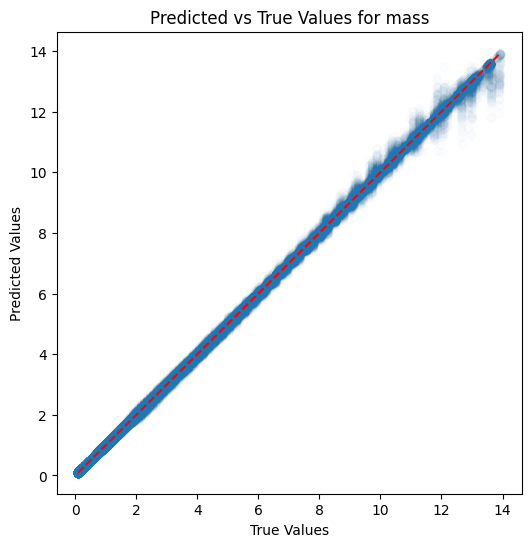

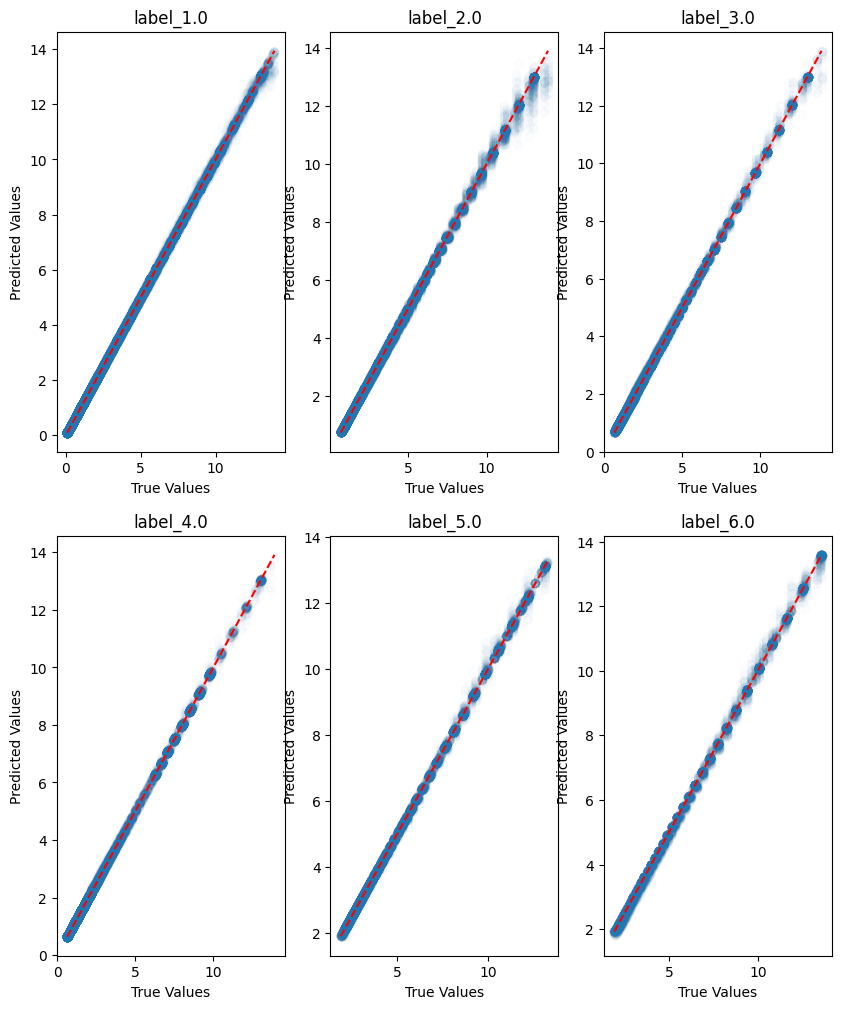

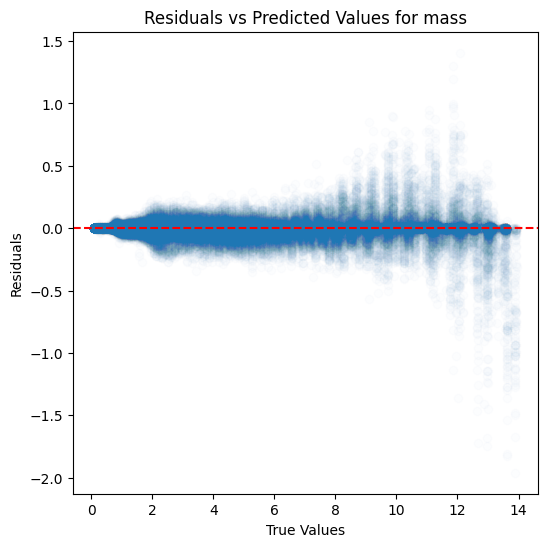

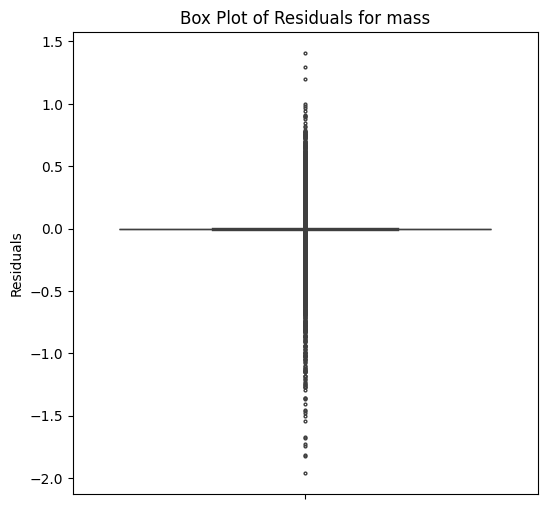

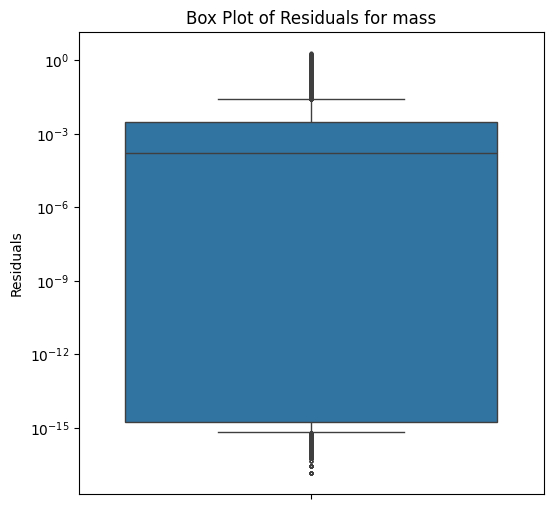

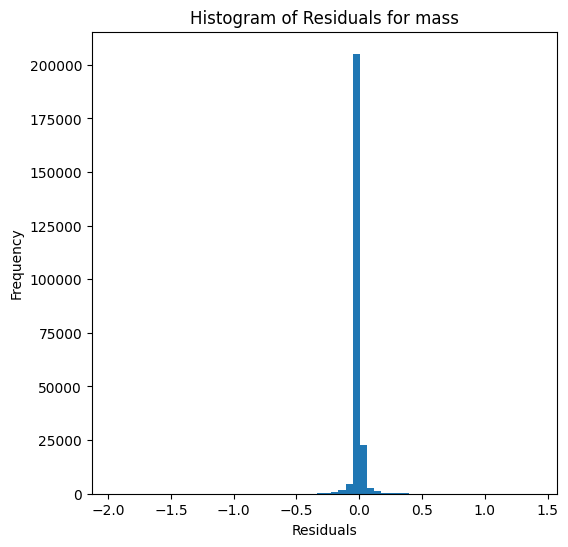

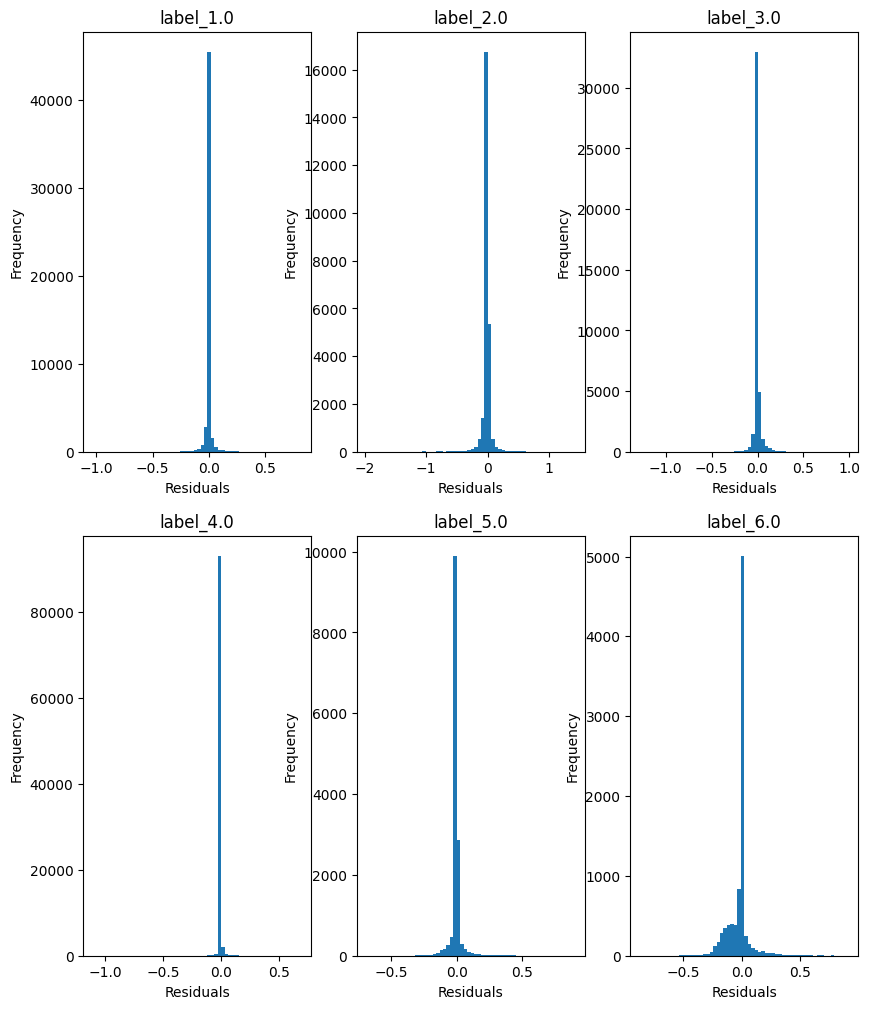

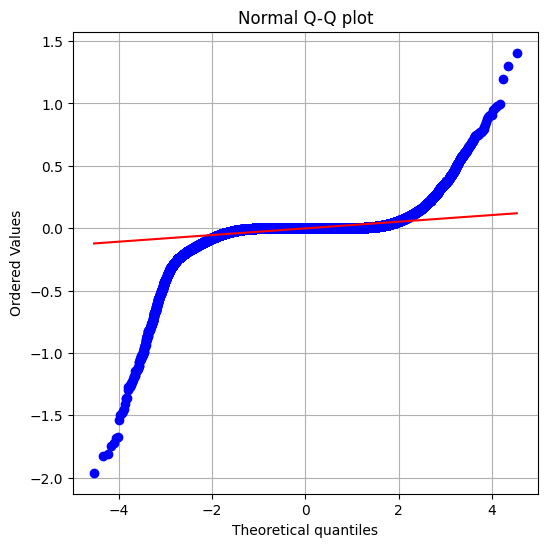

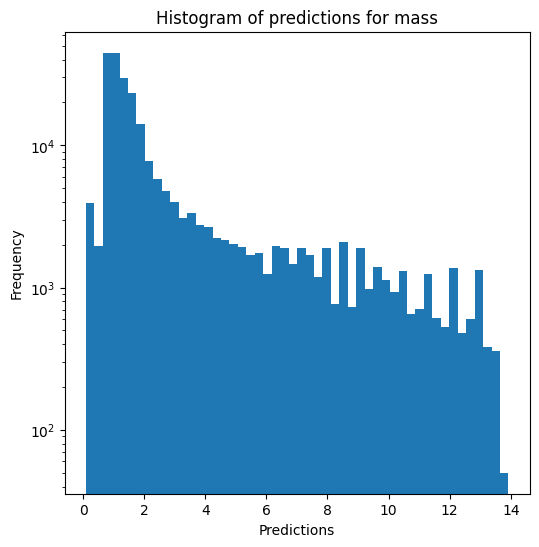

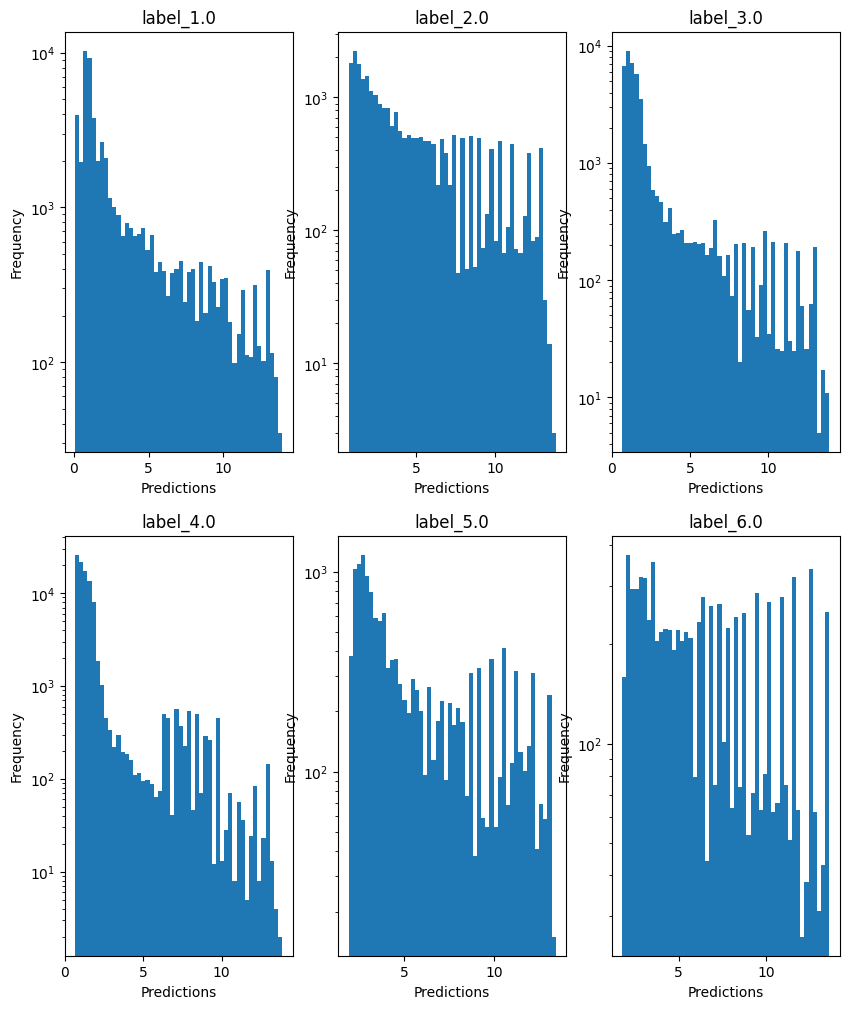

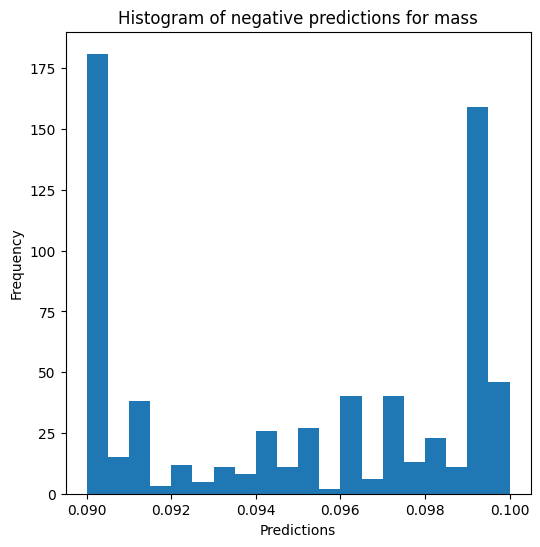

no negative values

radius results for the label category with a value of 1.0
  value range :  0.1056 - 14.75
  RVE :  0.9998446432670012
  RMSE :  0.020307726636801054
  MAE :  0.006337988864367448
  MedAE :  0.0005399999999911032
  CORR :  0.9999223532278803
  MAX_ER :  0.6192000000000029
  Percentiles : 
    75th percentile :  0.003430000000000266
    90th percentile :  0.016884999999998707
    95th percentile :  0.03333750000000213
    99th percentile :  0.0883670000000012

radius results for the label category with a value of 2.0
  value range :  1.047 - 287.4
  RVE :  0.999300001683418
  RMSE :  0.9719433657505888
  MAE :  0.15442288733560194
  MedAE :  0.0070499999999992236
  CORR :  0.9996638424064246
  MAX_ER :  35.18999999999991
  Percentiles : 
    75th percentile :  0.04299999999998905
    90th percentile :  0.21640000000000564
    95th percentile :  0.5107250000000476
    99th percentile :  2.6763010000000835

radius results for the label category with a value of 3.0
  val

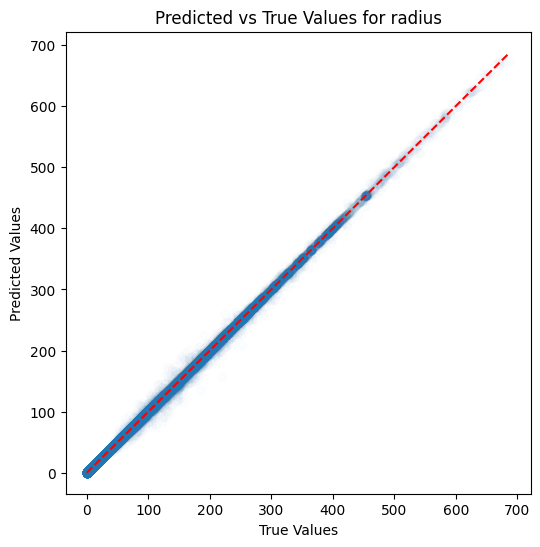

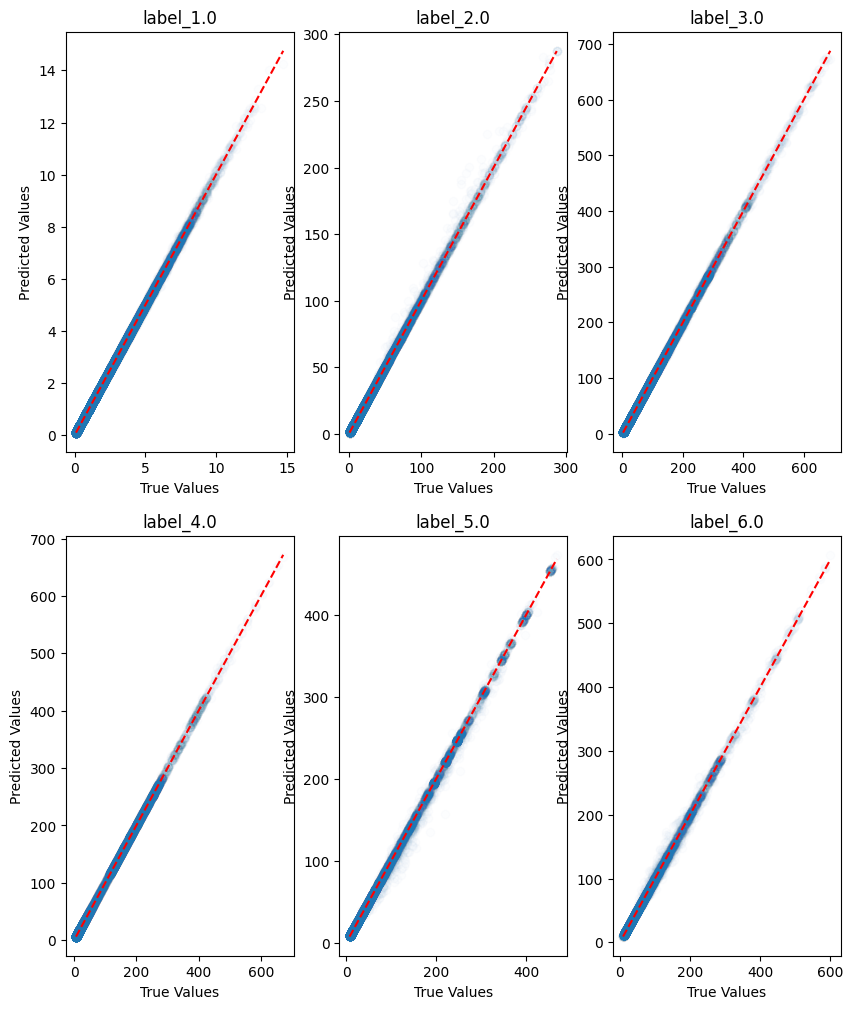

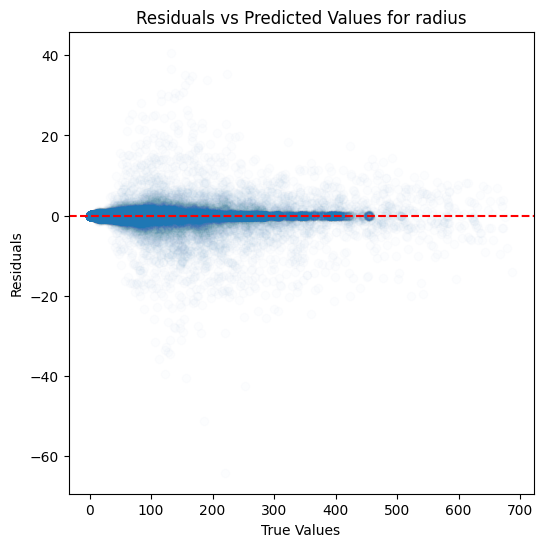

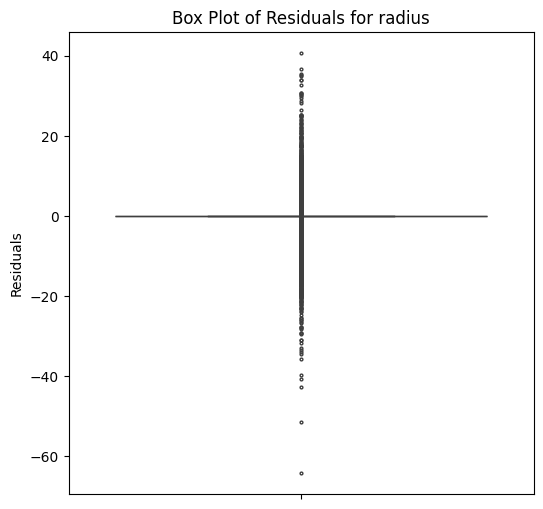

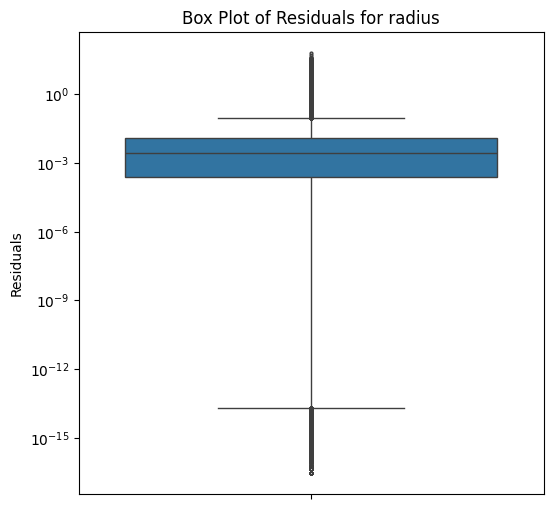

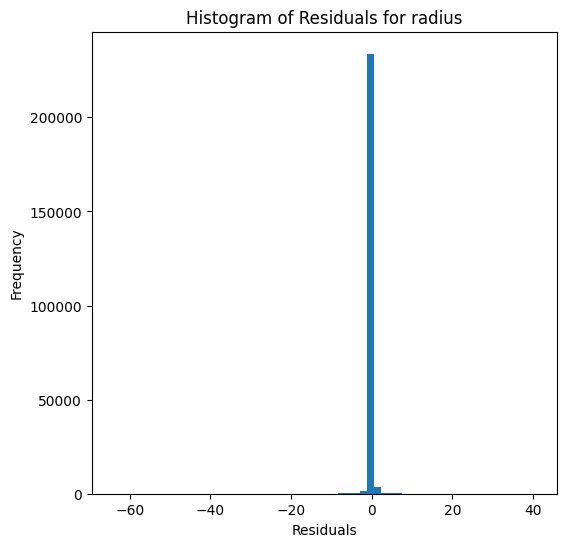

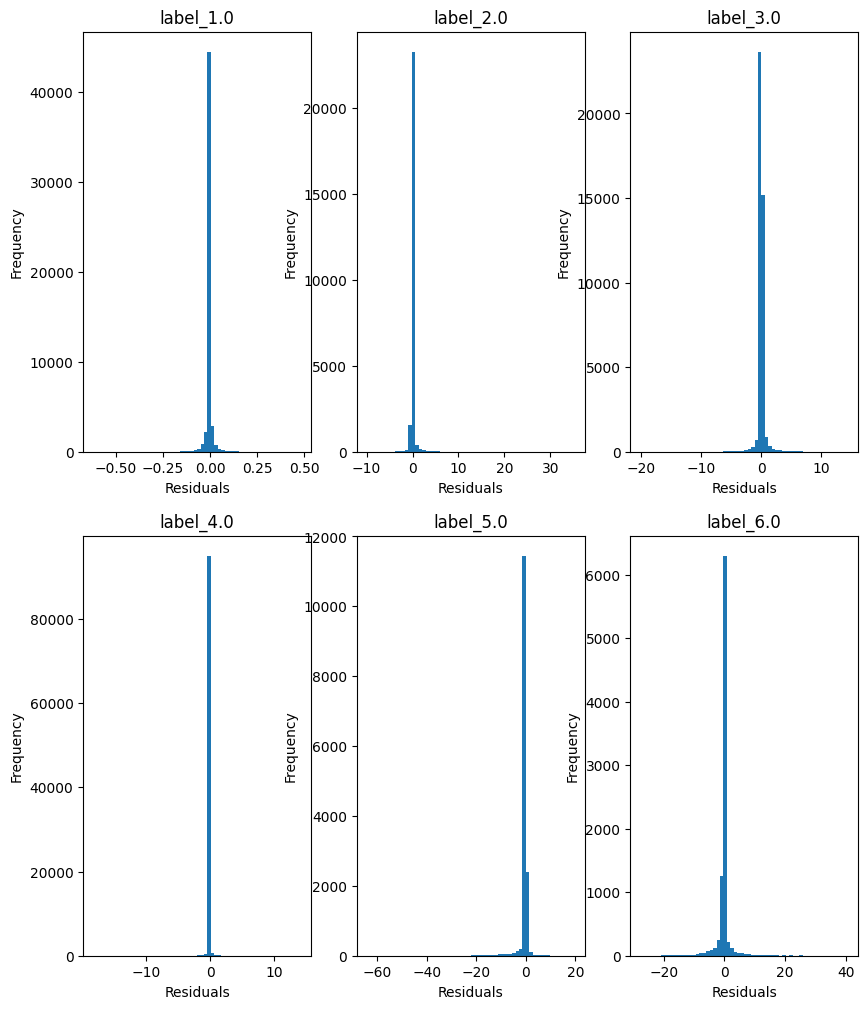

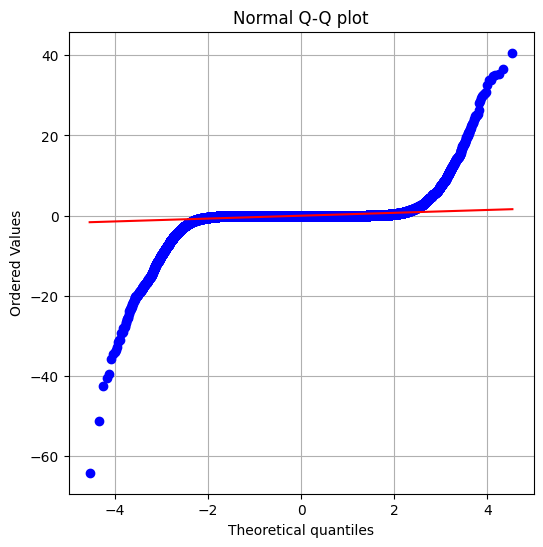

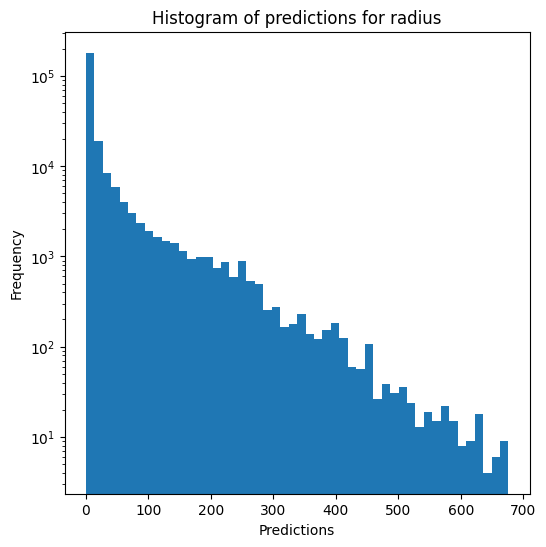

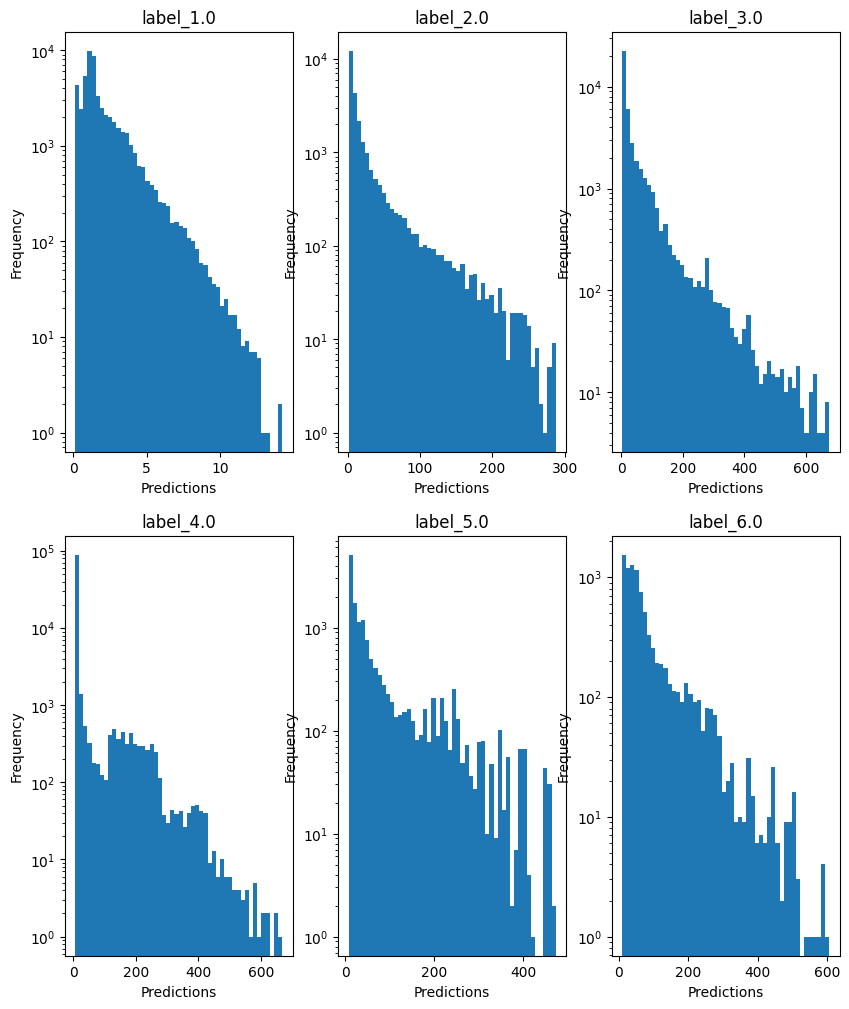

Saving predictions and results...


In [16]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [17]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9991350851722829
  RMSE :  0.0887554156625211
  MAE :  0.046886387633201056
  MedAE :  0.020626248836517425
  CORR :  0.999567813034968
  MAX_ER :  1.4695928878784184
  Percentiles : 
    75th percentile :  0.05201218032836952
    90th percentile :  0.11996983242034909
    95th percentile :  0.18982356643676757
    99th percentile :  0.37039495620727525

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.999888070822217
  RMSE :  0.03612342170599431
  MAE :  0.02399718580019451
  MedAE :  0.01514275693893452
  CORR :  0.9999466740441237
  MAX_ER :  0.3200783462524406
  Percentiles : 
    75th percentile :  0.031249127388000564
    90th percentile :  0.05624012413024876
    95th percentile :  0.07732287445068352
    99th percentile :  0.129936

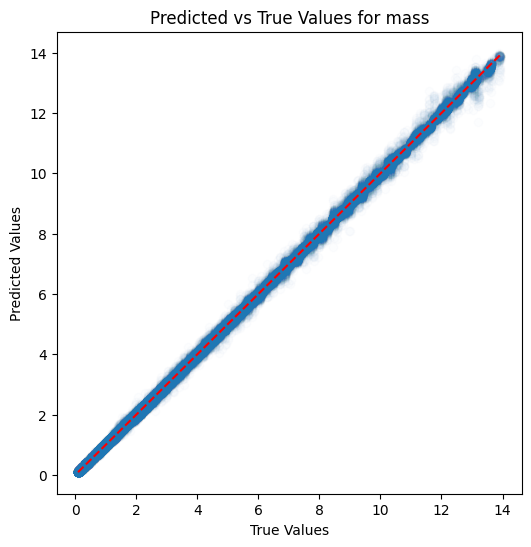

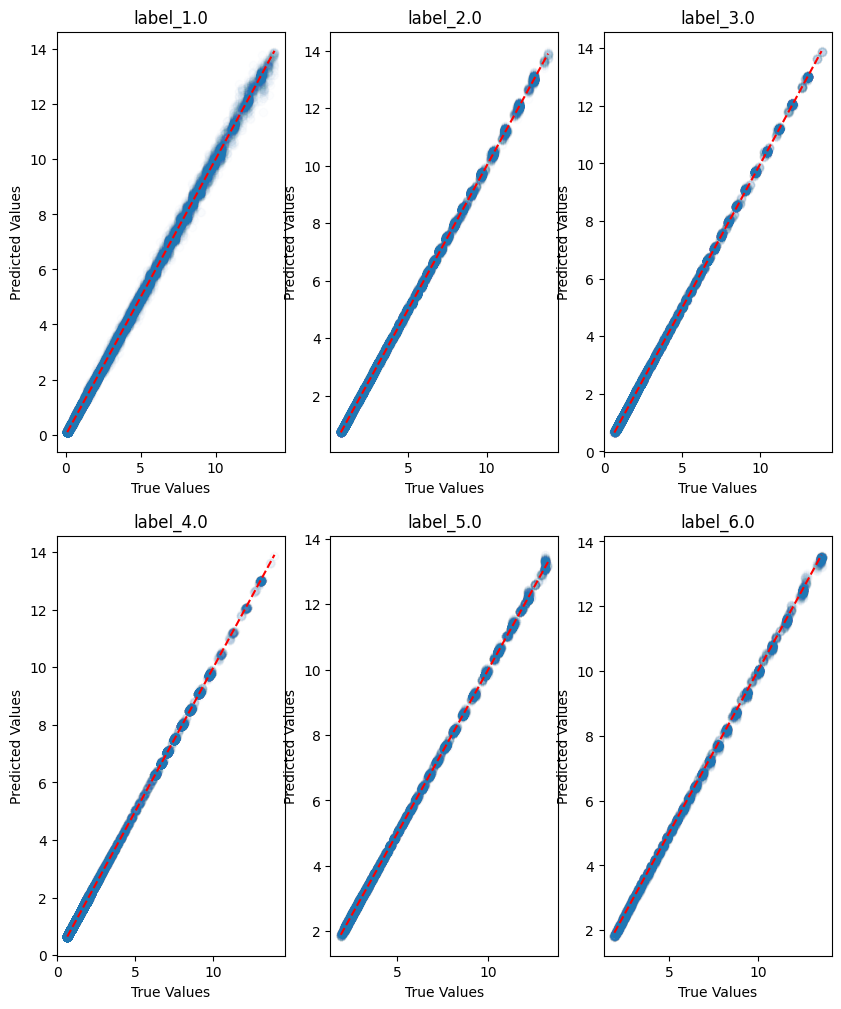

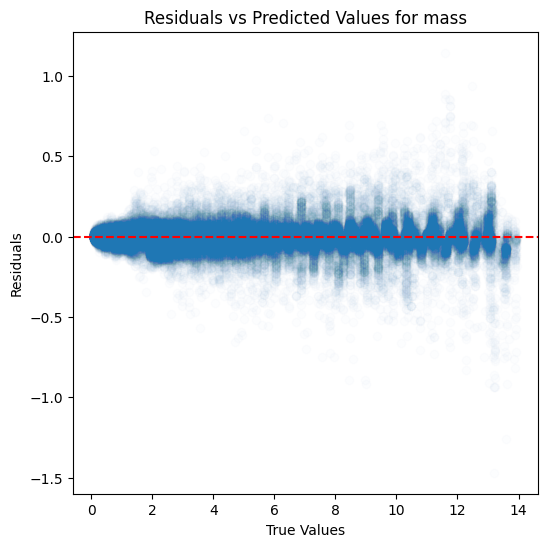

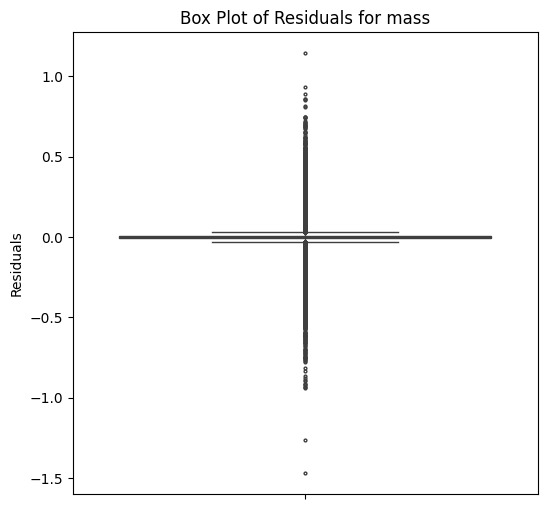

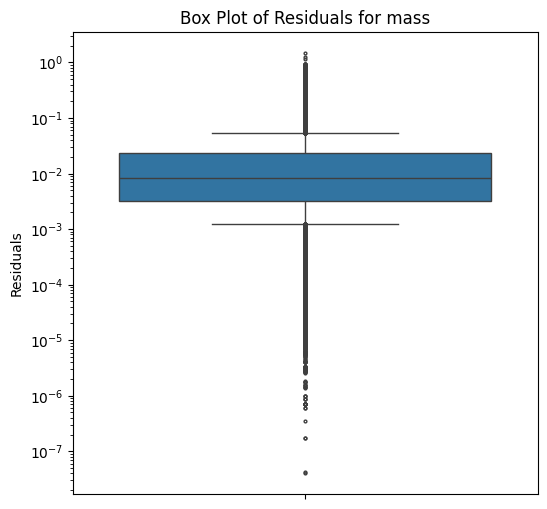

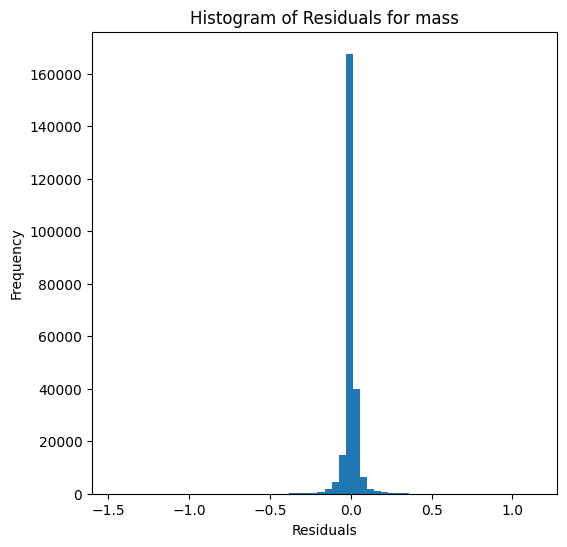

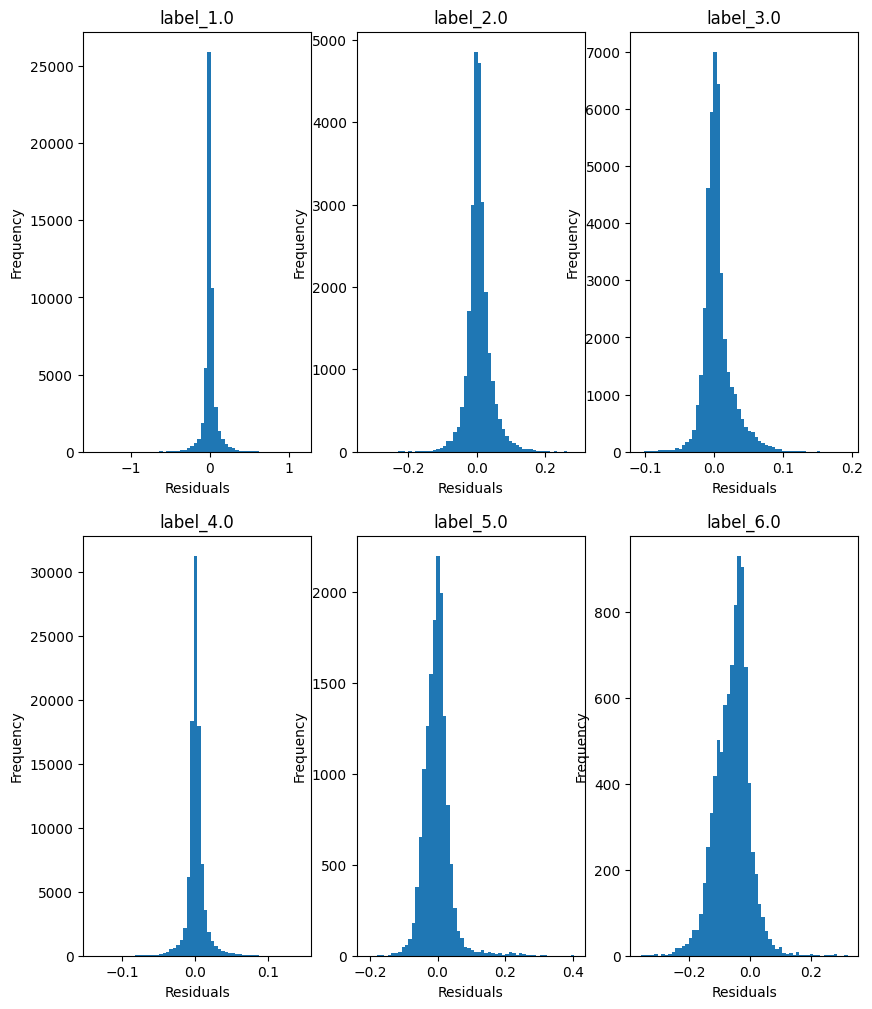

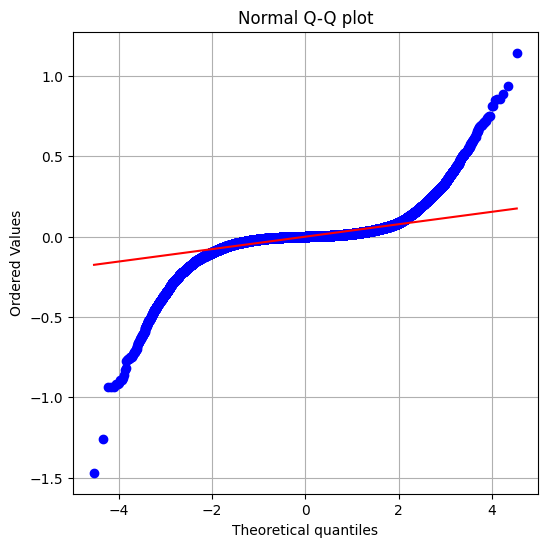

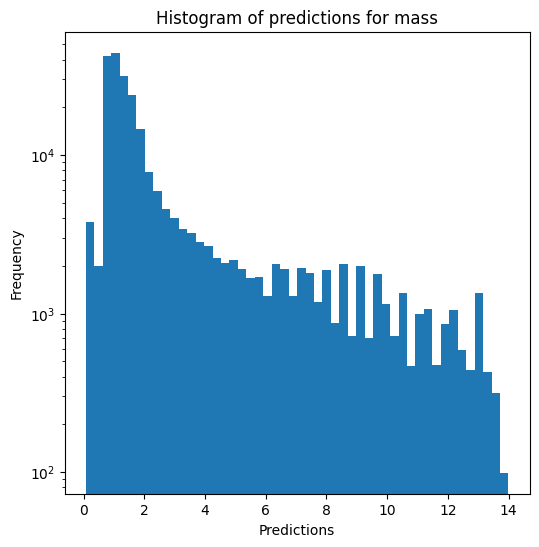

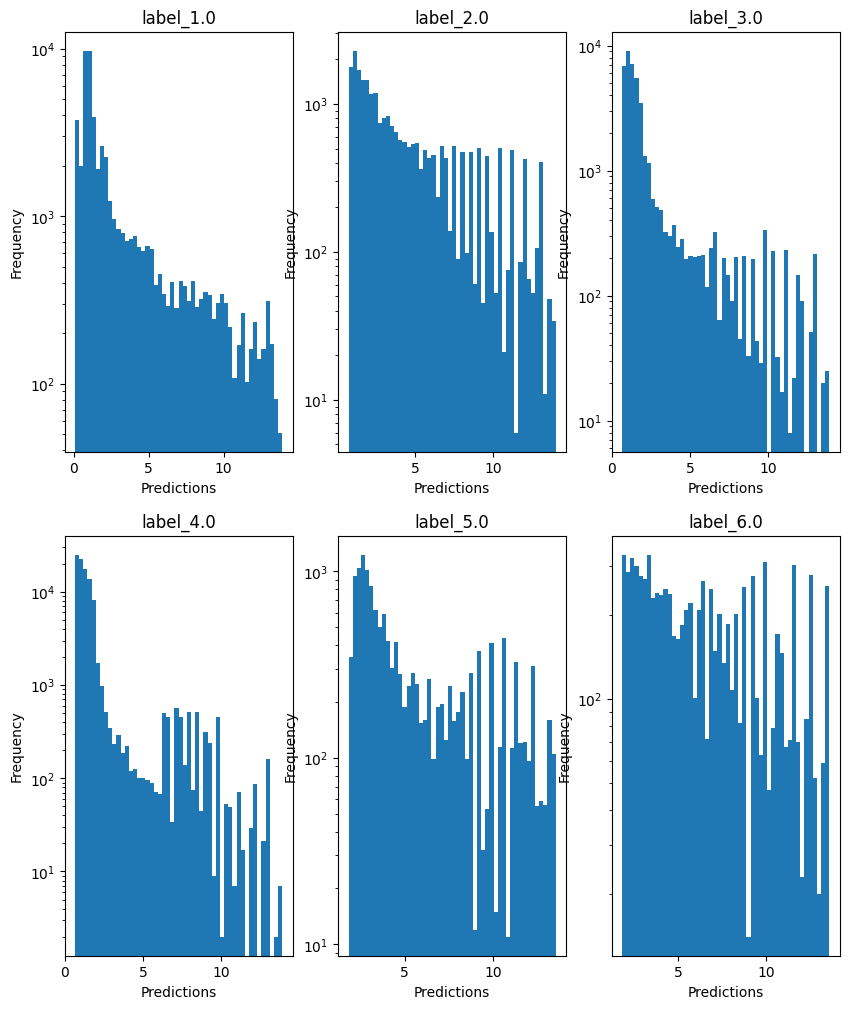

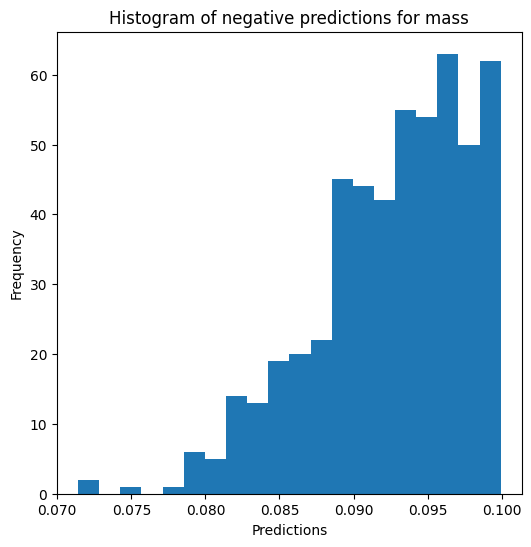


radius results for the label category with a value of 1.0
  value range :  0.1056 - 14.75
  RVE :  0.9926516845452369
  RMSE :  0.13948730361290304
  MAE :  0.08837361081573138
  MedAE :  0.05626776487827295
  CORR :  0.9963418655447543
  MAX_ER :  2.4021702575683594
  Percentiles : 
    75th percentile :  0.11294104218482975
    90th percentile :  0.198056426525116
    95th percentile :  0.2746241416931152
    99th percentile :  0.4977267652511593

radius results for the label category with a value of 2.0
  value range :  1.047 - 287.4
  RVE :  0.997828514317641
  RMSE :  1.7139996684673702
  MAE :  0.623667663366785
  MedAE :  0.20300175857543934
  CORR :  0.9989662786905698
  MAX_ER :  41.562396240234364
  Percentiles : 
    75th percentile :  0.49122354602813734
    90th percentile :  1.3118879699707016
    95th percentile :  2.5437209472656184
    99th percentile :  7.78458718566894

radius results for the label category with a value of 3.0
  value range :  1.94 - 687.5
  RVE :  

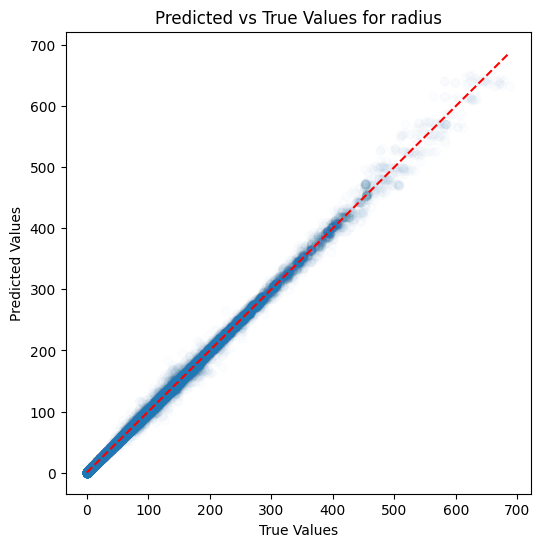

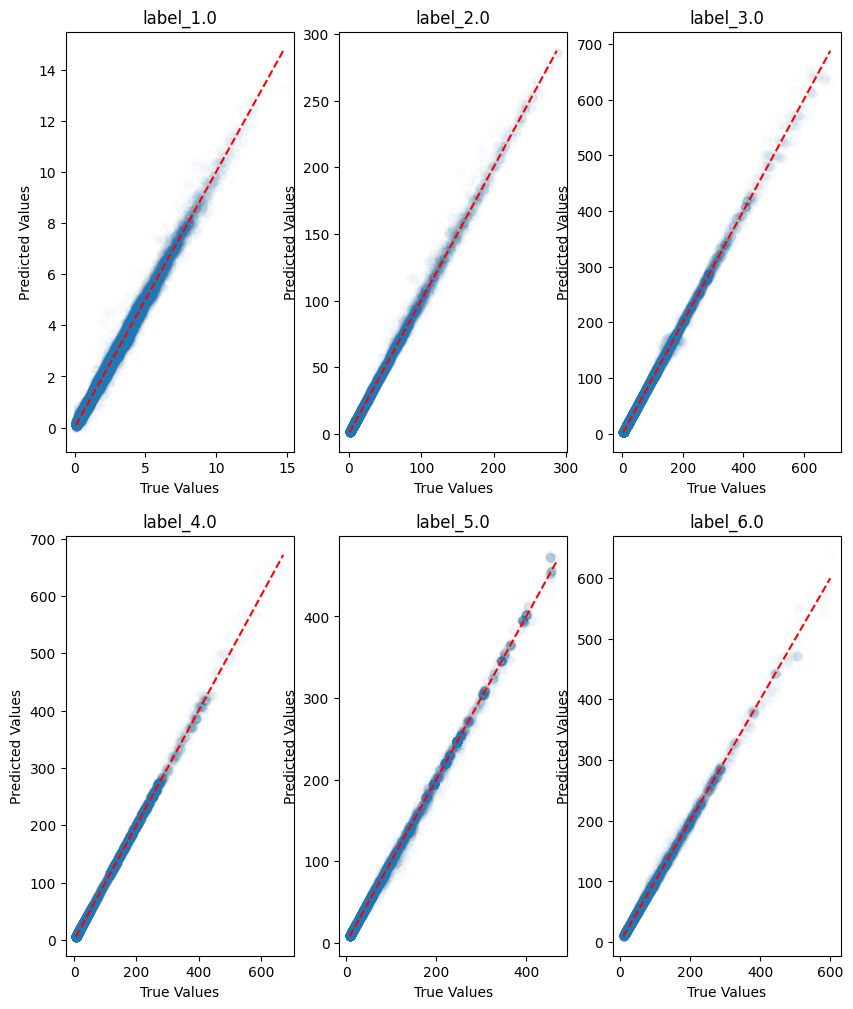

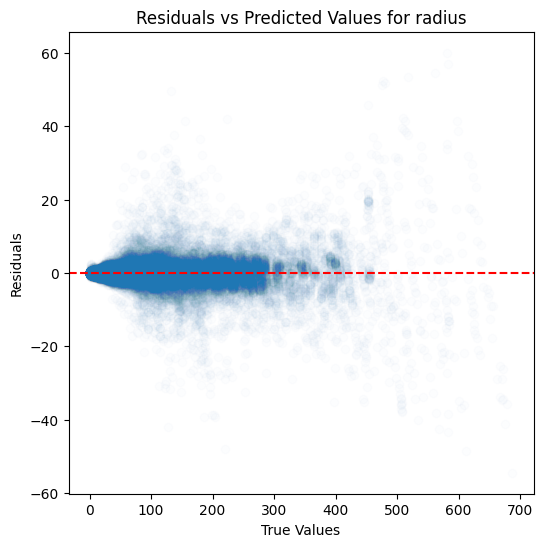

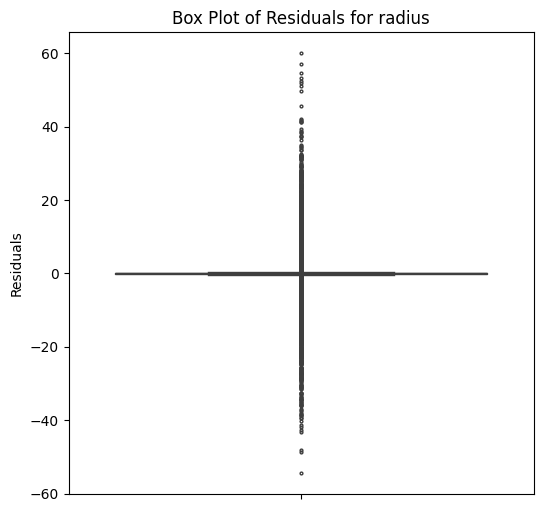

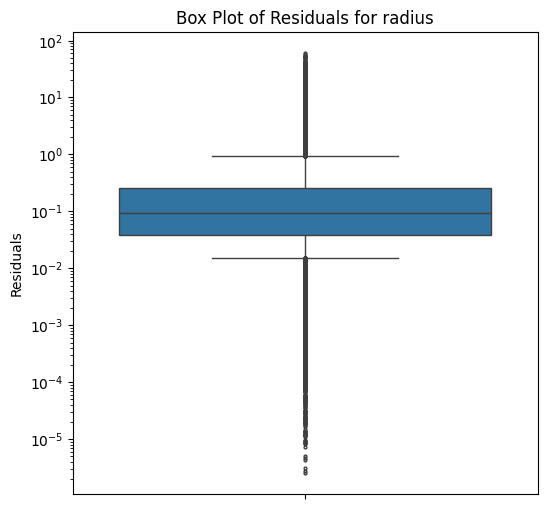

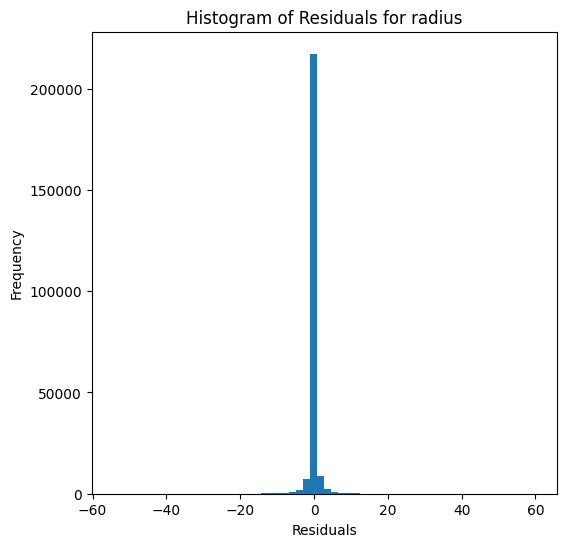

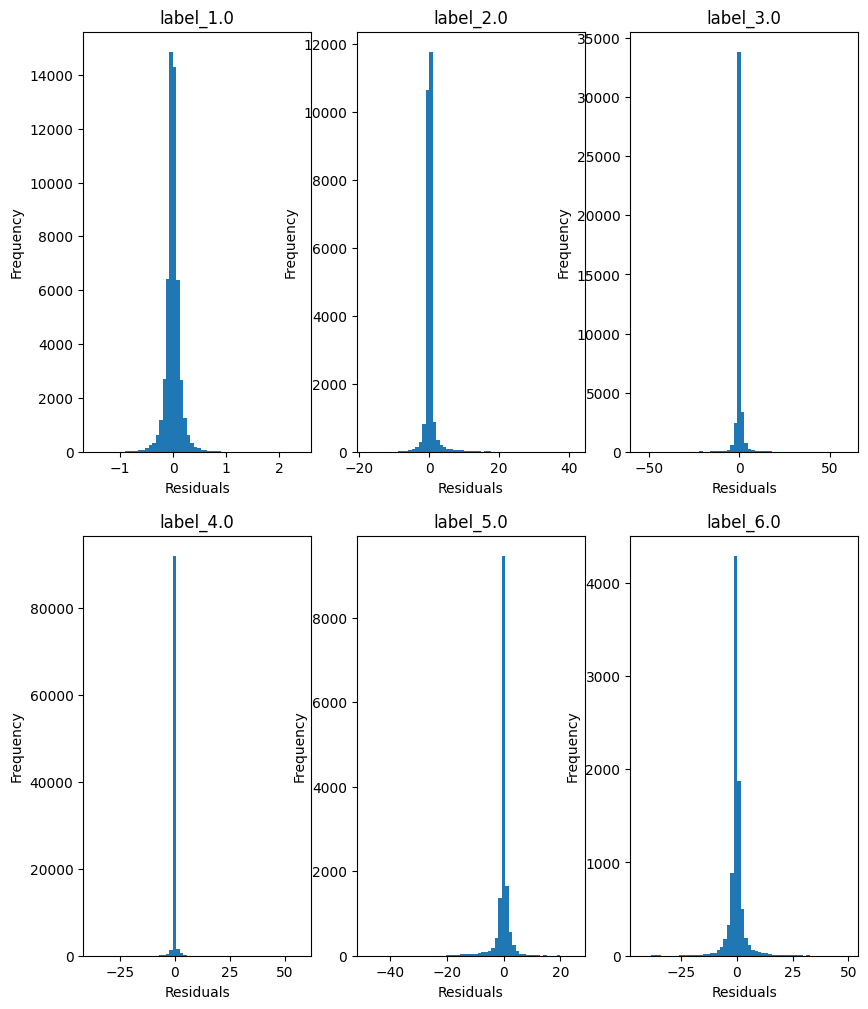

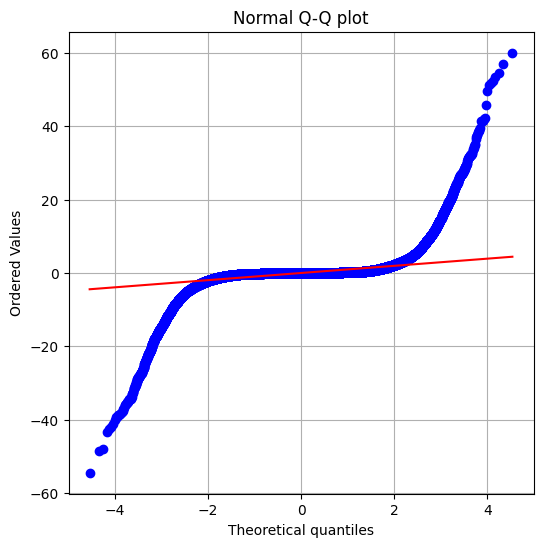

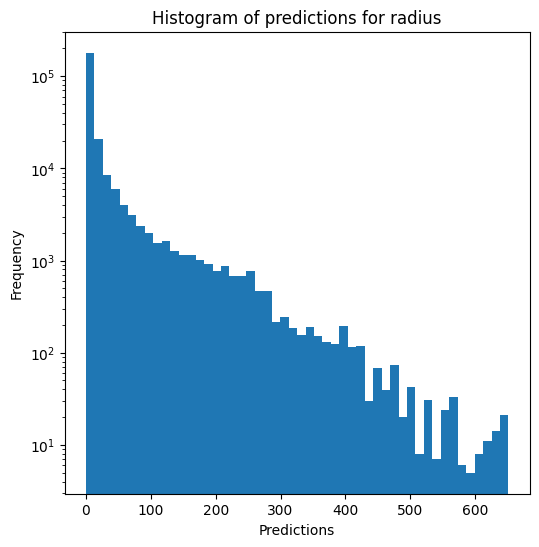

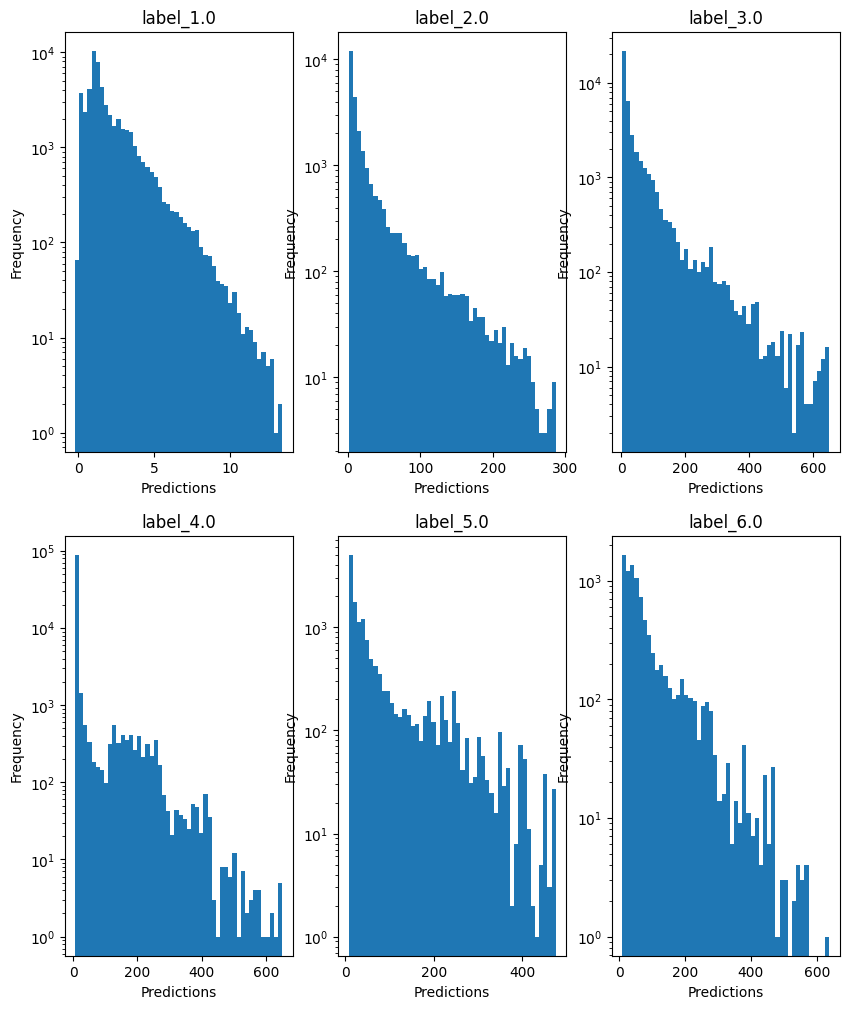

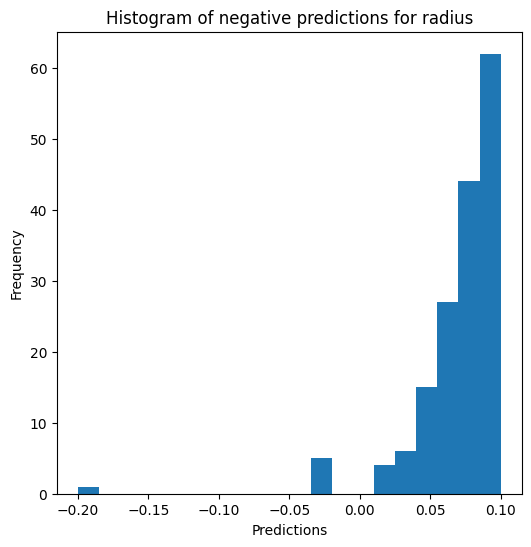

Saving predictions and results...


In [18]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [19]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_power train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


1.7006056234160427
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


1.6212960879443141
3 

...

1.6673319593660472
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


1.67993966316529
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


1.7206638329504245

Evaluating predictions...

mass results for the label category with a value of 1.0
  value range :  0.09 - 13.943
  RVE :  0.9880657381725698
  RMSE :  0.3296631224925543
  MAE :  0.19185794206754414
  MedAE :  0.09975079756928834
  CORR :  0.9940381120747241
  MAX_ER :  4.488039522399619
  Percentiles : 
    75th percentile :  0.22697970797202582
    90th percentile :  0.4810807561317665
    95th percentile :  0.6794738665749982
    99th percentile :  1.2883187910432161

mass results for the label category with a value of 2.0
  value range :  0.726 - 13.901
  RVE :  0.9960435540765181
  RMSE :  0.21737792164316902
  MAE :  0.1447213322087682
  MedAE :  0.0952475568769866
  CORR :  0.9980527260107239
  MAX_ER :  2.0335261932043327
  Percentiles : 
    75th percentile :  0.17843930576231248
    90th percentile :  0.3294948094215141
    95th percentile :  0.46563060066524986
    99th percentile :  0.8073631937693586

mass results for the label category with a value of

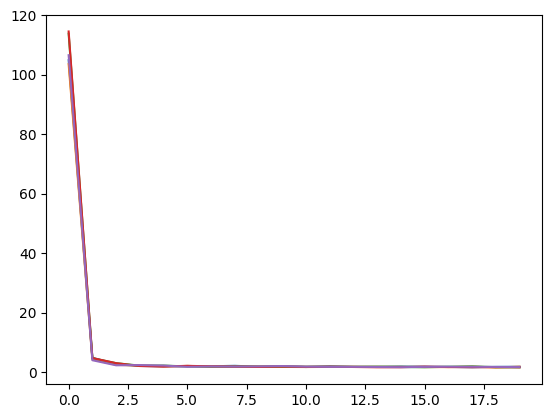

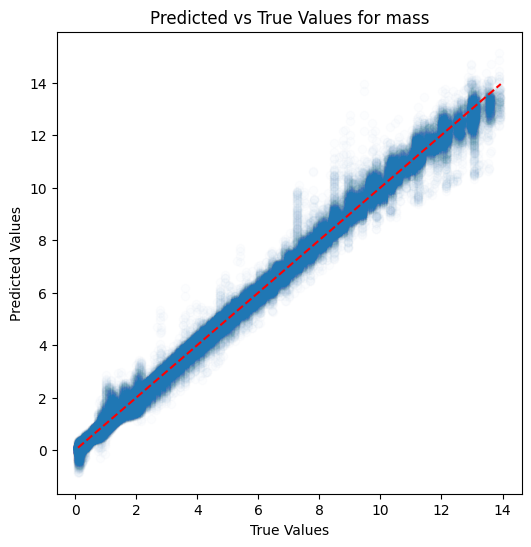

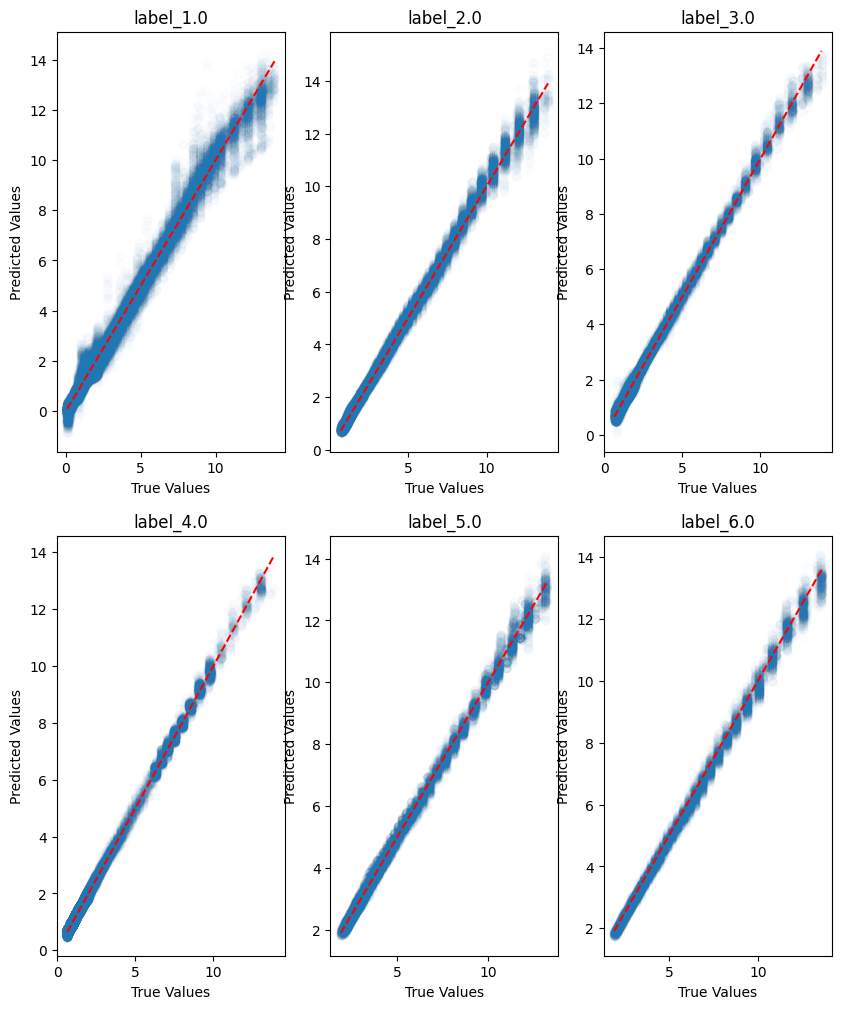

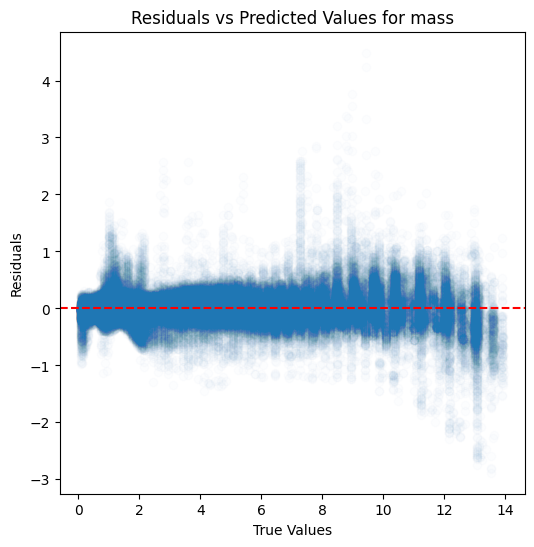

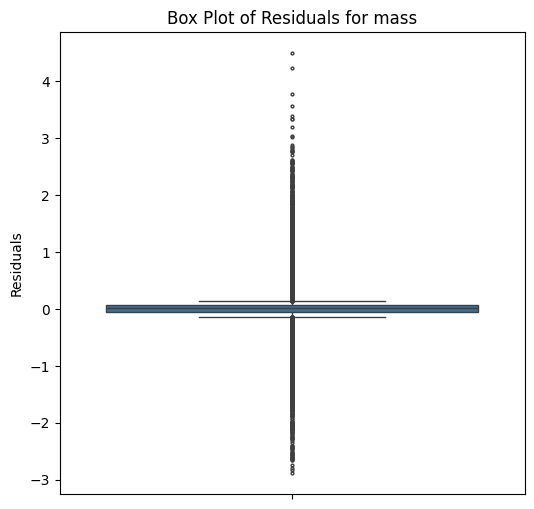

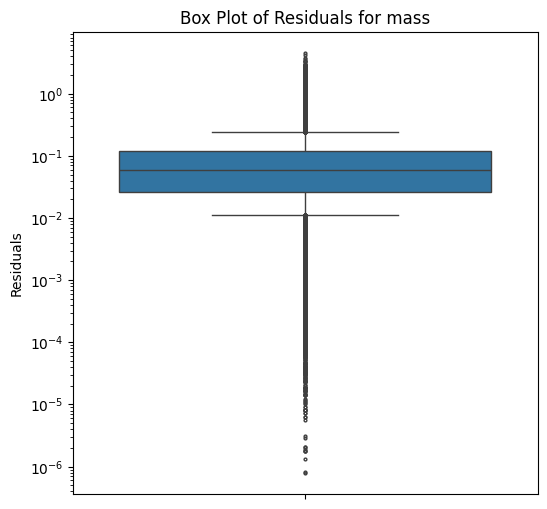

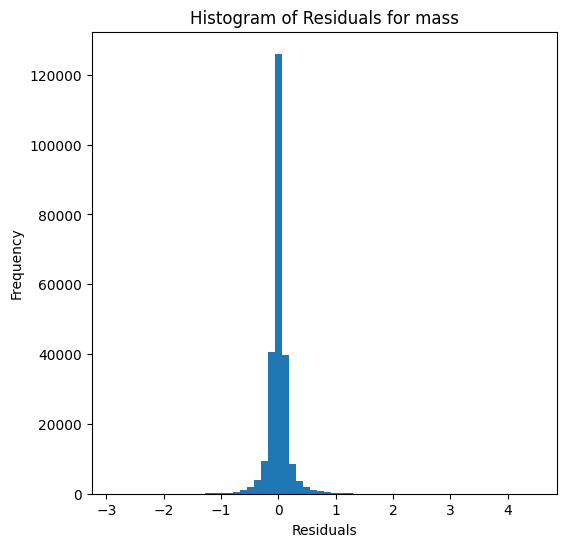

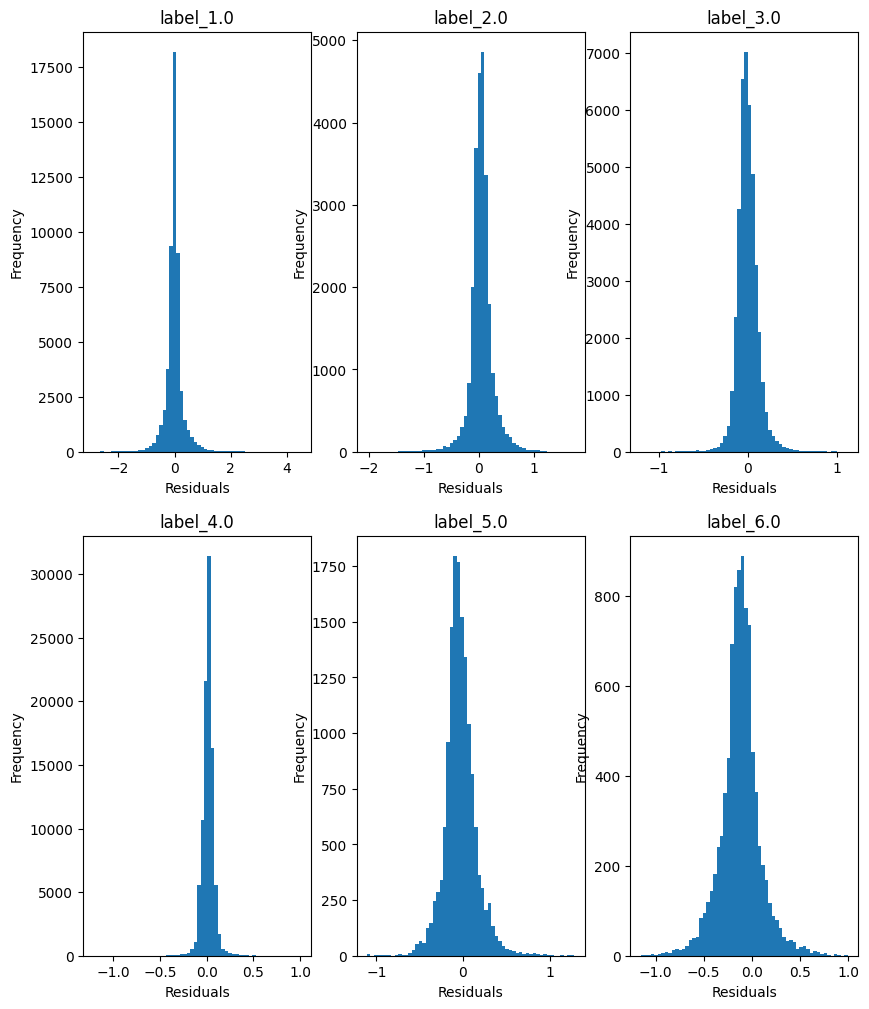

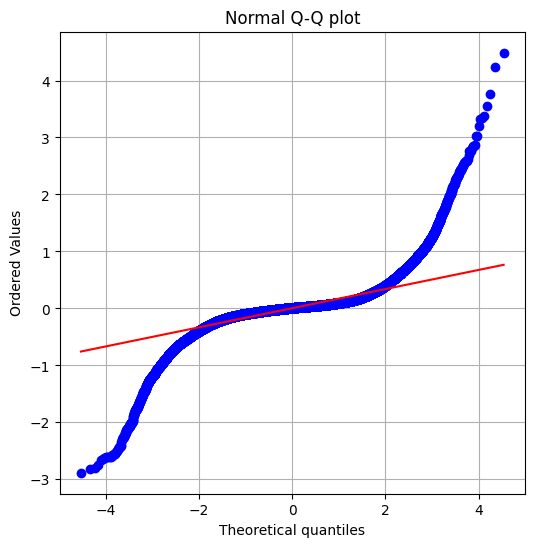

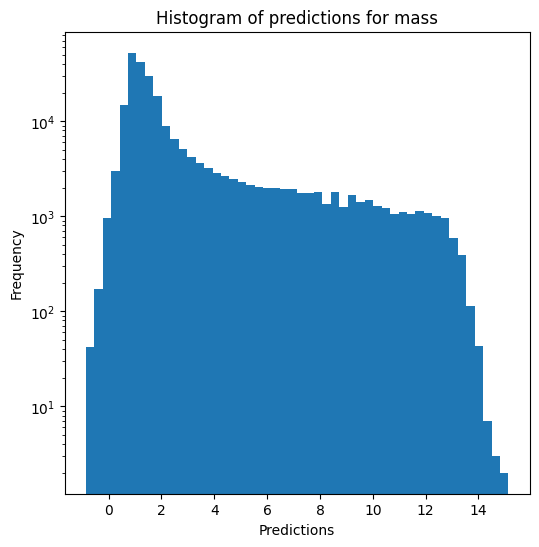

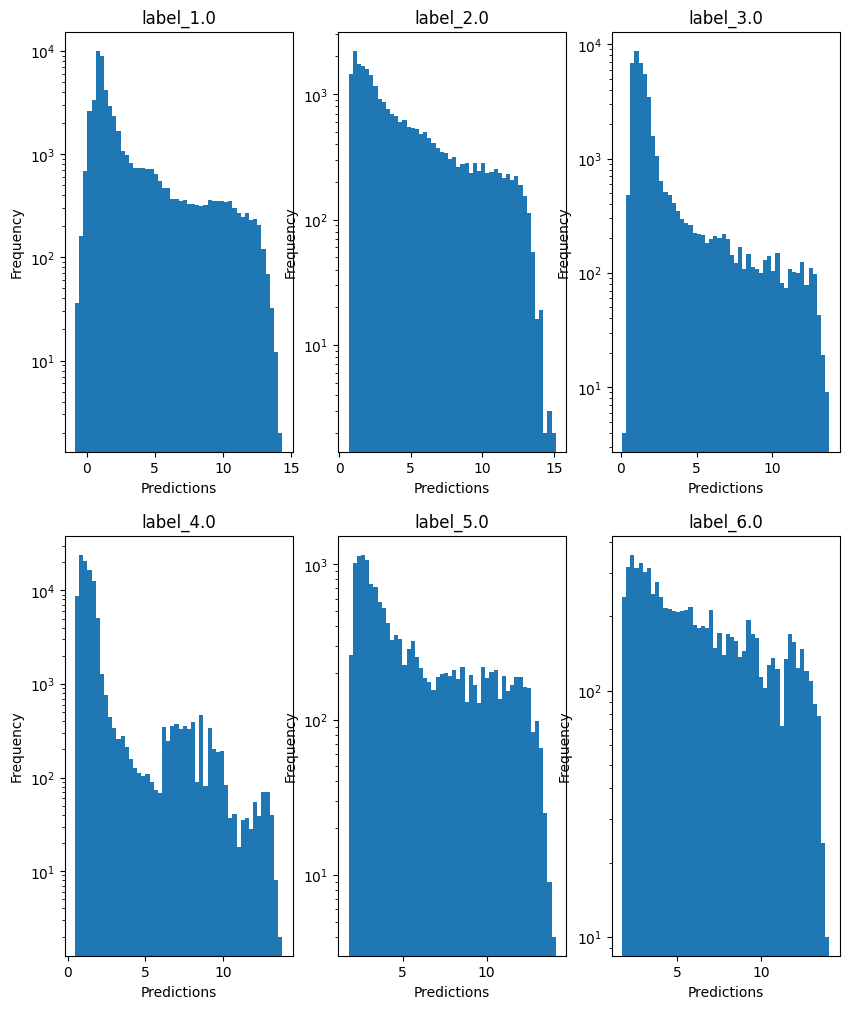

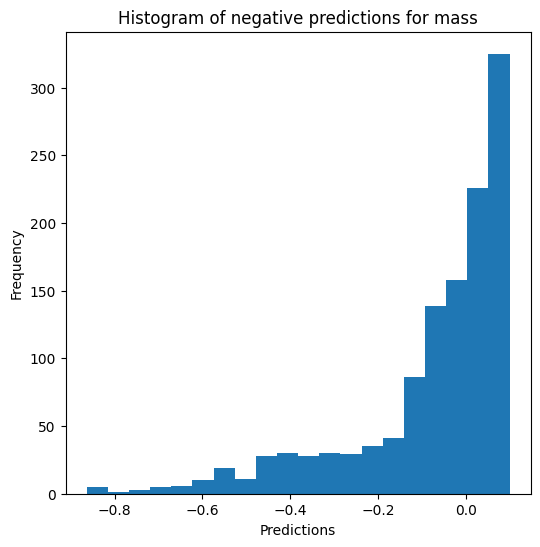


radius results for the label category with a value of 1.0
  value range :  0.1056 - 14.75
  RVE :  0.9915519905321799
  RMSE :  0.14975762962268413
  MAE :  0.1029766432854946
  MedAE :  0.07517099969586205
  CORR :  0.9958157210827338
  MAX_ER :  1.4323970875029088
  Percentiles : 
    75th percentile :  0.13506899712690762
    90th percentile :  0.21341217544773478
    95th percentile :  0.28788773597513756
    99th percentile :  0.5538664670588899

radius results for the label category with a value of 2.0
  value range :  1.047 - 287.4
  RVE :  0.9878631259361265
  RMSE :  4.176361823631127
  MAE :  1.2399546549363212
  MedAE :  0.1647454475167014
  CORR :  0.9975071475855408
  MAX_ER :  41.75483842278521
  Percentiles : 
    75th percentile :  0.45320108804352444
    90th percentile :  2.1487460820255198
    95th percentile :  6.584100620132596
    99th percentile :  24.389118895593505

radius results for the label category with a value of 3.0
  value range :  1.94 - 687.5
  RVE :

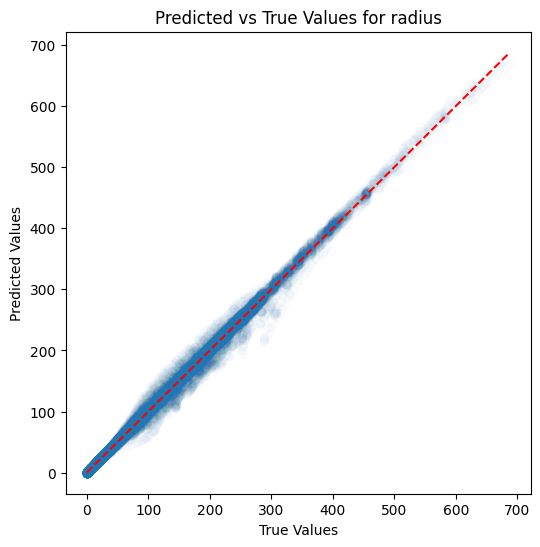

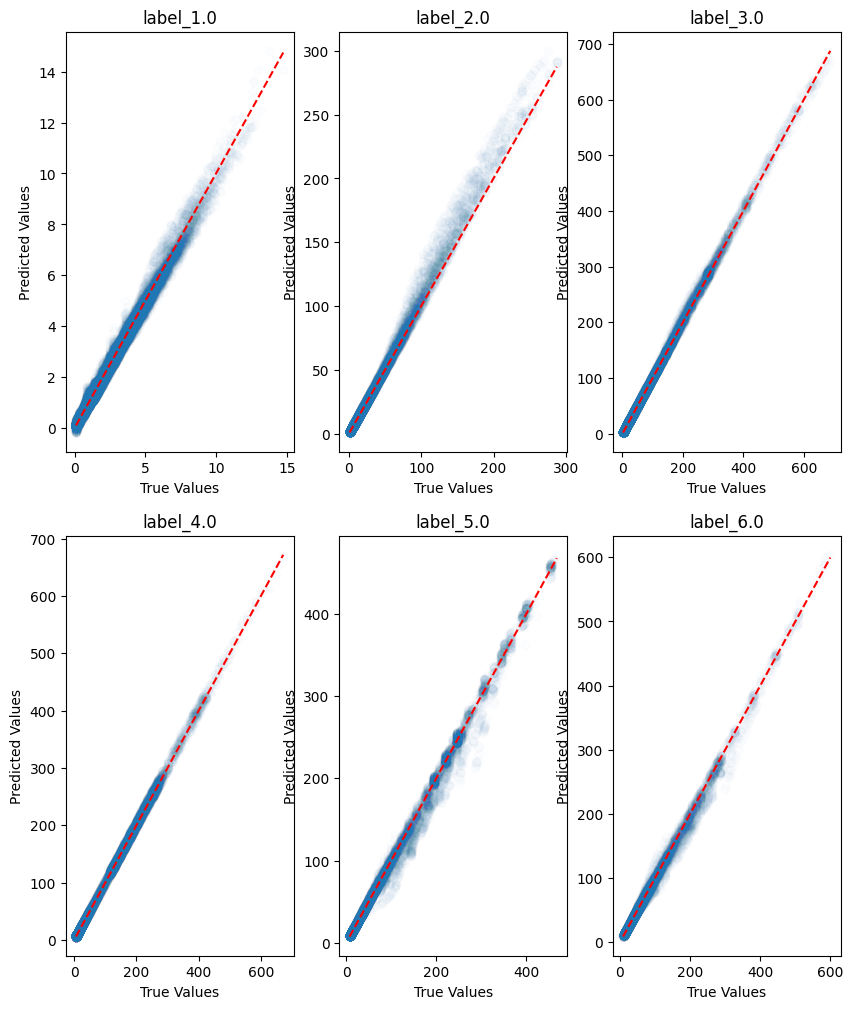

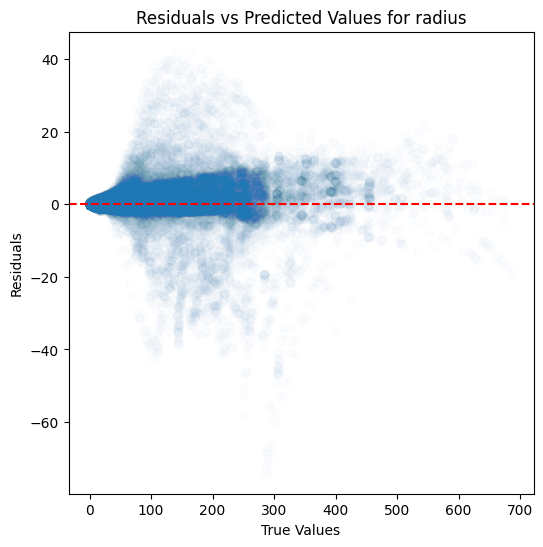

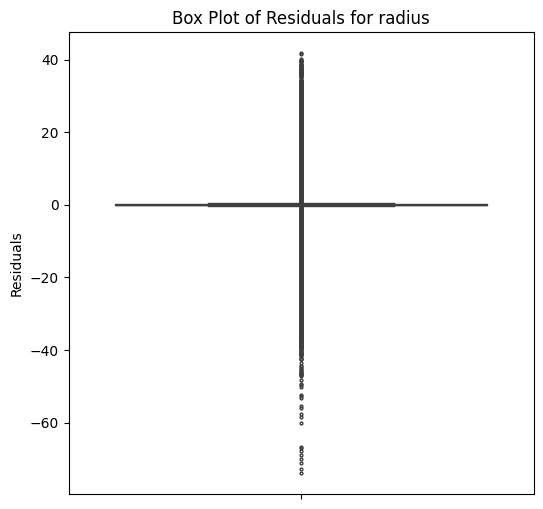

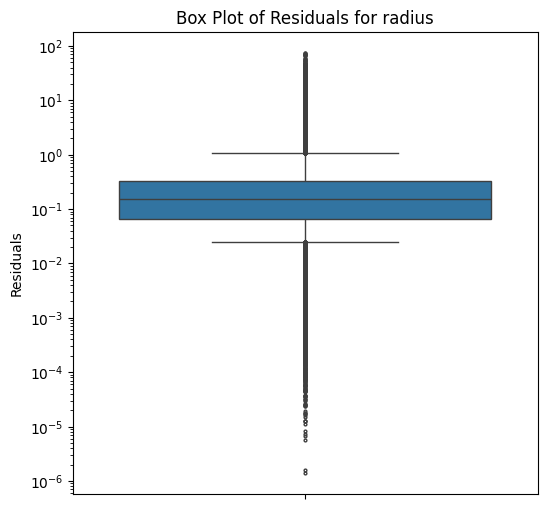

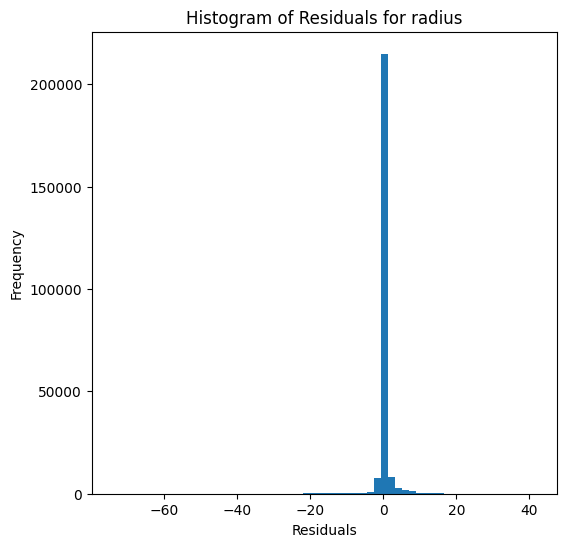

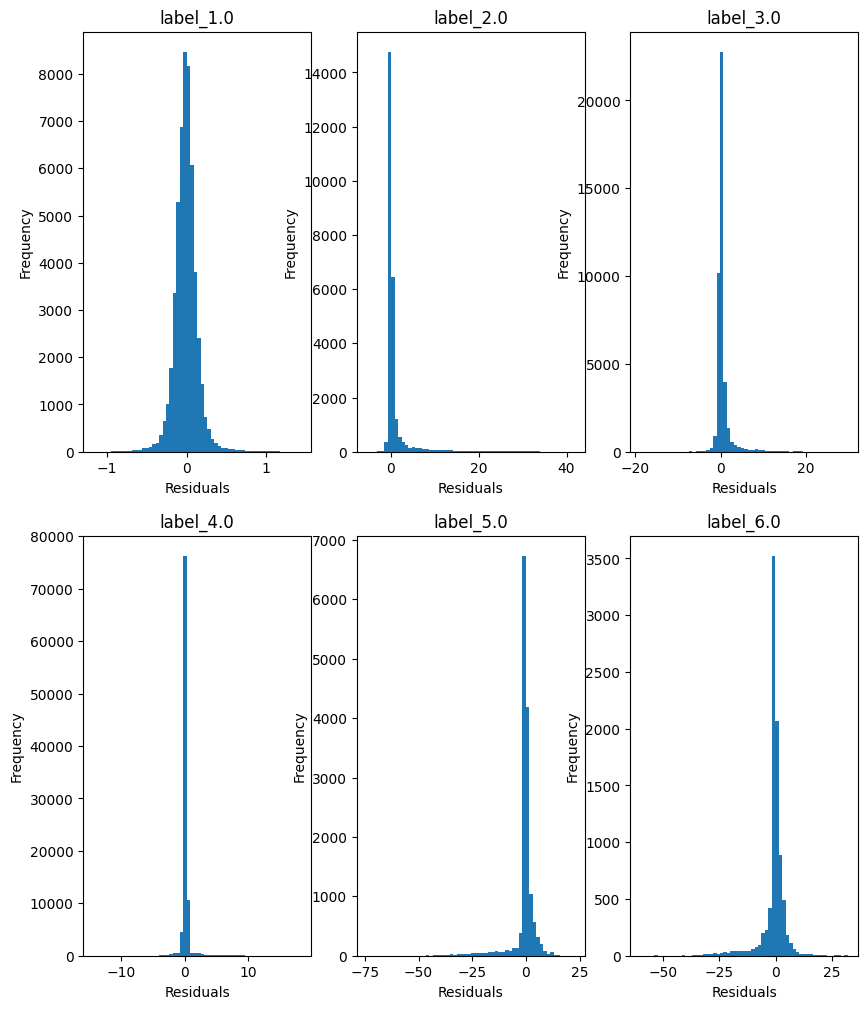

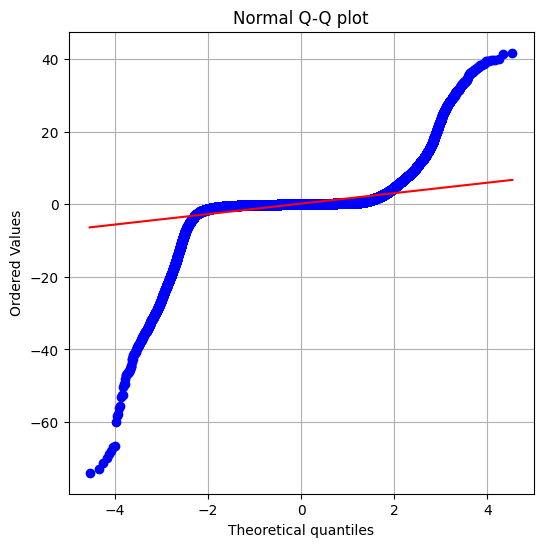

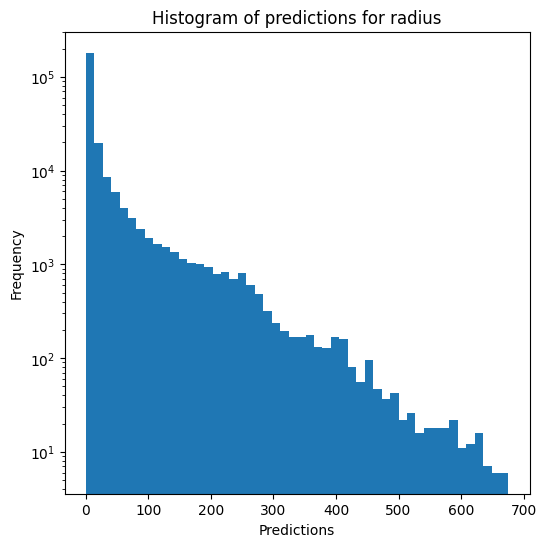

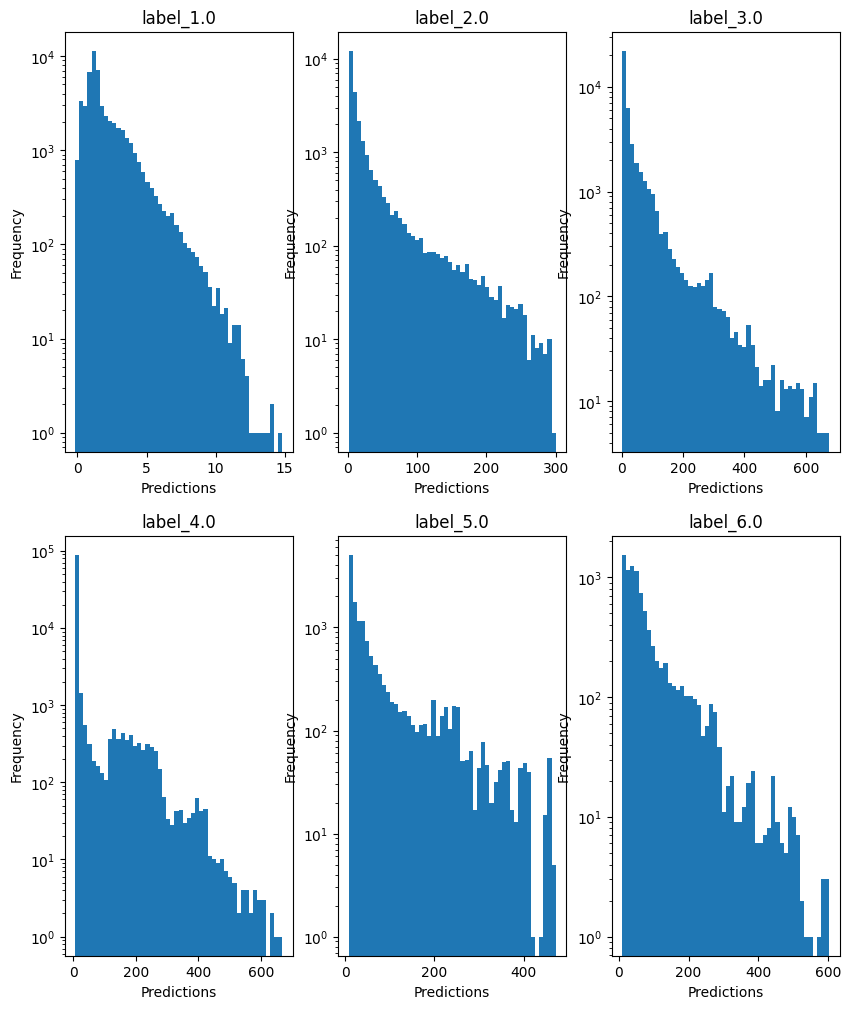

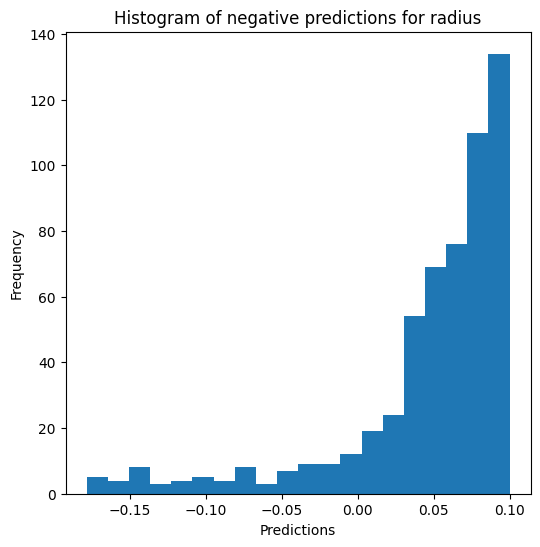

Saving predictions and results...


In [20]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon